# Advanced Customer Lifestyle Segmentation Model

**An end-to-end unsupervised ML pipeline classifying retail banking customers
into behavioural lifestyle segments using 12 months of transaction history.**

---

### Architecture

| Section | Description |
|---------|-------------|
| 1 | Import libraries |
| 2 | Synthetic data generation - monthly raw parquets saved to `data/cache/` |
| 3 | Classification engine - debit, POS/card, and credit classified month-by-month |
| 4 | Feature engineering - streaming aggregation from classified parquets |
| 5 | Segmentation model - MiniBatchKMeans + 10-rule priority engine |
| 6 | Model evaluation - silhouette score, segment profiles, tier coverage |
| 7 | Customer profile lookup |
| 8 | Export - drift detection, TOP5 spend/credit, recommended products |

### Folder structure
```
customer-lifestyle-segmentation/
├── customer_lifestyle_segmentation.ipynb
├── requirements.txt
├── README.md
├── data/cache/
│   ├── df_debit_{month}.parquet          # raw non-card debit by month
│   ├── df_pos_{month}.parquet            # raw card transactions by month
│   ├── df_credit_{month}.parquet         # raw credit inflows by month
│   ├── df_debit_classified_{month}.parquet
│   ├── df_pos_classified_{month}.parquet
│   ├── df_credit_classified_{month}.parquet
│   └── terminal_profile.pkl
└── outputs/
    └── customer_lifestyle_segments_YYYYMMDD.csv
```

> All data is **synthetically generated**. No real customer data is used.
> The pipeline mirrors a production deployment serving millions of retail banking customers.


## Section 1: Import Libraries

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
usage: python.exe c:\Users\DELL\AppData\Roaming\Python\Python314\Scripts\jupyter
       [-h] [--json] [--debug]
       [--version | --config-dir | --data-dir | --runtime-dir | --paths |
       subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: builder console dejavu events execute kernel kernelspec
lab labextension labhub migrate nbco

In [3]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'
os.environ['LOKY_MAX_CPU_COUNT']   = '4'

import re
import gc
import glob
import pickle
import calendar
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f"Libraries loaded | Pandas {pd.__version__} | NumPy {np.__version__}")


Libraries loaded | Pandas 3.0.2 | NumPy 2.4.4


## Section 2: Synthetic Data Generation

Generates **10,000 customers** across **12 months** (Jul 2025 – Jun 2026).

Three source tables are generated per month and saved to `data/cache/`:
- `df_debit_{month}.parquet` --- non-card debit (NIP, MOBILE, USSD, BRANCH)
- `df_pos_{month}.parquet` --- card transactions (POS + ATM) with MCC codes
- `df_credit_{month}.parquet` --- inflow transactions (salary, loan)

Narrations are seeded from the same keyword dictionaries used in Section 3,
so the classification engine produces realistic tier distributions.


In [4]:
# Configuration
N_CUSTOMERS     = 10_000
ANALYSIS_MONTHS = 12
ANALYSIS_START  = pd.Timestamp('2025-07-01')
ANALYSIS_END    = ANALYSIS_START + pd.DateOffset(months=ANALYSIS_MONTHS) - pd.Timedelta(days=1)
SEED            = 42

CACHE_DIR  = os.path.join('data', 'cache')
OUTPUT_DIR = 'outputs'
os.makedirs(CACHE_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

_MONTH_ABBR = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}
_MONTH_ABBR_REV = {v: k for k, v in _MONTH_ABBR.items()}

def _parse_month_sfx(sfx):
    return datetime(int(sfx[3:]), _MONTH_ABBR[sfx[:3]], 1)

# Auto-detect TARGET_MONTHS from cache (like production: rolling last 12)
_pat = re.compile(r'df_debit_([a-z]+\d{4})\.parquet')
_all_months = sorted(
    {m.group(1) for f in os.listdir(CACHE_DIR)
     if (m := _pat.match(f)) and 'classified' not in f},
    key=_parse_month_sfx
)

MONTH_SUFFIXES = []
dt = ANALYSIS_START
for _ in range(ANALYSIS_MONTHS):
    MONTH_SUFFIXES.append(f"{_MONTH_ABBR_REV[dt.month]}{dt.year}")
    dt = dt + pd.DateOffset(months=1)

TARGET_MONTHS = set(MONTH_SUFFIXES)
months_sorted = sorted(TARGET_MONTHS, key=_parse_month_sfx)
PRIOR_6M      = set(months_sorted[:6])
RECENT_6M     = set(months_sorted[6:])
REPORT_DATE   = ANALYSIS_END.strftime('%Y-%m-%d')

print(f"Analysis window : {ANALYSIS_START.date()} to {ANALYSIS_END.date()}")
print(f"Months          : {MONTH_SUFFIXES}")
print(f"Cache folder    : {os.path.abspath(CACHE_DIR)}")
print(f"Prior 6M        : {sorted(PRIOR_6M,  key=_parse_month_sfx)}")
print(f"Recent 6M       : {sorted(RECENT_6M, key=_parse_month_sfx)}")


Analysis window : 2025-07-01 to 2026-06-30
Months          : ['jul2025', 'aug2025', 'sep2025', 'oct2025', 'nov2025', 'dec2025', 'jan2026', 'feb2026', 'mar2026', 'apr2026', 'may2026', 'jun2026']
Cache folder    : c:\G_py\customer_lifestyle_segmentation\data\cache
Prior 6M        : ['jul2025', 'aug2025', 'sep2025', 'oct2025', 'nov2025', 'dec2025']
Recent 6M       : ['jan2026', 'feb2026', 'mar2026', 'apr2026', 'may2026', 'jun2026']


In [5]:
# Lifestyle archetypes
ARCHETYPES = {
    'STRATEGIST': {
        'weight':0.07,'salary_prob':0.95,'pos_share':0.15,'atm_share':0.05,
        'avg_monthly_debit':(250_000,900_000),'avg_monthly_credit':(300_000,1_200_000),
        'spending_mix':{'SAVINGS_AND_INVESTMENTS':0.22,'FOOD_AND_DINING':0.10,
            'INSURANCE':0.08,'UTILITIES':0.07,'TRANSPORT_AND_LOGISTICS':0.06,
            'HEALTH':0.05,'TRANSFER_TO_OTHERS':0.12,'TRANSFER_TO_SELF_CROSSBANK':0.18,
            'PROFESSIONAL_SERVICES':0.06,'ENTERTAINMENT':0.04,'OTHER_CREDIT':0.02},
    },
    'WEALTH BUILDER': {
        'weight':0.09,'salary_prob':0.85,'pos_share':0.20,'atm_share':0.05,
        'avg_monthly_debit':(150_000,600_000),'avg_monthly_credit':(180_000,750_000),
        'spending_mix':{'SAVINGS_AND_INVESTMENTS':0.28,'FOOD_AND_DINING':0.12,
            'TRANSFER_TO_SELF_CROSSBANK':0.15,'UTILITIES':0.08,'TRANSPORT_AND_LOGISTICS':0.07,
            'HEALTH':0.05,'TRANSFER_TO_OTHERS':0.08,'ENTERTAINMENT':0.06,
            'EDUCATION':0.05,'OTHER_CREDIT':0.06},
    },
    'FAMILY BUILDER': {
        'weight':0.14,'salary_prob':0.75,'pos_share':0.25,'atm_share':0.10,
        'avg_monthly_debit':(80_000,350_000),'avg_monthly_credit':(100_000,400_000),
        'spending_mix':{'EDUCATION':0.18,'FOOD_AND_DINING':0.14,'UTILITIES':0.10,
            'HEALTH':0.08,'TRANSFER_TO_OTHERS':0.12,'HOME_AND_RENT':0.10,
            'TRANSPORT_AND_LOGISTICS':0.08,'SOCIAL_EVENTS':0.07,
            'SAVINGS_AND_INVESTMENTS':0.05,'OTHER_CREDIT':0.08},
    },
    'FINANCIALLY COMMITTED': {
        'weight':0.11,'salary_prob':0.80,'pos_share':0.12,'atm_share':0.15,
        'avg_monthly_debit':(60_000,250_000),'avg_monthly_credit':(70_000,300_000),
        'spending_mix':{'LOAN_REPAYMENT':0.28,'FOOD_AND_DINING':0.13,'UTILITIES':0.10,
            'TRANSPORT_AND_LOGISTICS':0.09,'DIGITAL_LENDING':0.10,'HOME_AND_RENT':0.09,
            'AIRTIME_AND_DATA':0.07,'TRANSFER_TO_OTHERS':0.07,'HEALTH':0.04,'OTHER_CREDIT':0.03},
    },
    'URBAN YOUNG PROFESSIONAL': {
        'weight':0.13,'salary_prob':0.70,'pos_share':0.35,'atm_share':0.08,
        'avg_monthly_debit':(50_000,200_000),'avg_monthly_credit':(55_000,230_000),
        'spending_mix':{'ENTERTAINMENT':0.18,'FOOD_AND_DINING':0.17,
            'TRANSPORT_AND_LOGISTICS':0.12,'AIRTIME_AND_DATA':0.10,'SHOPPING':0.09,
            'PERSONAL_CARE':0.07,'STREAMING_SUBSCRIPTION':0.06,'UTILITIES':0.06,
            'TRANSFER_TO_OTHERS':0.08,'OTHER_CREDIT':0.07},
    },
    'INFORMAL / TRADER': {
        'weight':0.12,'salary_prob':0.10,'pos_share':0.10,'atm_share':0.20,
        'avg_monthly_debit':(100_000,800_000),'avg_monthly_credit':(120_000,900_000),
        'spending_mix':{'TRANSFER_TO_OTHERS':0.42,'BUSINESS_EXPENSE':0.18,
            'FOOD_AND_DINING':0.09,'UTILITIES':0.06,'TRANSPORT_AND_LOGISTICS':0.07,
            'AIRTIME_AND_DATA':0.06,'SAVINGS_AND_INVESTMENTS':0.05,'OTHER_CREDIT':0.07},
    },
    'ACTIVE BETTOR': {
        'weight':0.08,'salary_prob':0.55,'pos_share':0.08,'atm_share':0.18,
        'avg_monthly_debit':(30_000,150_000),'avg_monthly_credit':(35_000,180_000),
        'spending_mix':{'BETTING_GAMES_AND_GAMBLING':0.35,'FOOD_AND_DINING':0.14,
            'AIRTIME_AND_DATA':0.12,'TRANSPORT_AND_LOGISTICS':0.08,'ENTERTAINMENT':0.10,
            'TRANSFER_TO_OTHERS':0.08,'UTILITIES':0.07,'OTHER_CREDIT':0.06},
    },
    'CASH DEPENDENT': {
        'weight':0.13,'salary_prob':0.40,'pos_share':0.05,'atm_share':0.50,
        'avg_monthly_debit':(20_000,100_000),'avg_monthly_credit':(22_000,110_000),
        'spending_mix':{'FOOD_AND_DINING':0.20,'AIRTIME_AND_DATA':0.15,'UTILITIES':0.12,
            'TRANSFER_TO_OTHERS':0.10,'TRANSPORT_AND_LOGISTICS':0.08,'OTHER_CREDIT':0.35},
    },
    'MINIMAL ACTIVITY': {
        'weight':0.13,'salary_prob':0.20,'pos_share':0.05,'atm_share':0.25,
        'avg_monthly_debit':(1_000,18_000),'avg_monthly_credit':(1_000,20_000),
        'spending_mix':{'AIRTIME_AND_DATA':0.30,'FOOD_AND_DINING':0.20,
            'TRANSFER_TO_OTHERS':0.20,'UTILITIES':0.15,'TRANSPORT_AND_LOGISTICS':0.05,
            'OTHER_CREDIT':0.10},
    },
}

rng_arch          = np.random.default_rng(SEED)
archetype_names   = list(ARCHETYPES.keys())
archetype_weights = np.array([ARCHETYPES[a]['weight'] for a in archetype_names])
archetype_weights /= archetype_weights.sum()
customer_archetype = rng_arch.choice(archetype_names, size=N_CUSTOMERS, p=archetype_weights)
customer_ids       = [f'CUST{str(i+1).zfill(7)}' for i in range(N_CUSTOMERS)]
df_customers       = pd.DataFrame({'CUSTOMER_ID': customer_ids, 'ARCHETYPE': customer_archetype})

# Stable salary flag per customer
rng_sal      = np.random.default_rng(SEED + 1)
IS_SALARY    = {cid: rng_sal.random() < ARCHETYPES[arch]['salary_prob']
                for cid, arch in zip(customer_ids, customer_archetype)}

# Customer names (used in Tier 2.9 cross-bank self-transfer detection)
FIRST_NAMES  = ['ADEBAYO','CHUKWUEMEKA','FATIMA','NGOZI','IBRAHIM','AISHA','OLUWASEUN',
                 'KEMI','SAMUEL','GRACE','EMEKA','TUNDE','FUNMI','OLUSEGUN','AMINA']
LAST_NAMES   = ['OKAFOR','ADELEKE','IBRAHIM','ABUBAKAR','NWACHUKWU','ADEYEMI','BELLO',
                 'OKONKWO','MUSA','OLADIPO','DANJUMA','LAWAL','EZE','USMAN','OGUNDELE']
rng_names    = np.random.default_rng(SEED + 2)
CUST_NAMES   = {cid: f"{rng_names.choice(FIRST_NAMES)} {rng_names.choice(LAST_NAMES)}"
                for cid in customer_ids}

print(f"Customers       : {N_CUSTOMERS:,}")
print(df_customers['ARCHETYPE'].value_counts().to_string())


Customers       : 10,000
ARCHETYPE
FAMILY BUILDER              1426
URBAN YOUNG PROFESSIONAL    1310
CASH DEPENDENT              1286
MINIMAL ACTIVITY            1267
INFORMAL / TRADER           1237
FINANCIALLY COMMITTED       1081
WEALTH BUILDER               904
ACTIVE BETTOR                776
STRATEGIST                   713


In [6]:
# Narration seed dictionaries (sampled during generation)
CAT_NARRATIONS = {
    'AIRTIME_AND_DATA'          : ['MTN AIRTIME RECHARGE','AIRTEL DATA SUBSCRIPTION','GLO AIRTIME VTU','9MOBILE DATA TOP UP','RECHARGE AIRTIME'],
    'UTILITIES'                 : ['EKEDC ELECTRICITY PAYMENT','IKEDC PREPAID METER','LAWMA WASTE BILL','AEDC ELECTRICITY','BUY POWER PREPAID'],
    'BETTING_GAMES_AND_GAMBLING': ['BET9JA DEPOSIT','SPORTYBET TRANSFER','BETWAY PAYMENT','BETKING DEPOSIT','1XBET WALLET'],
    'FOOD_AND_DINING'           : ['CHICKEN REPUBLIC PAYMENT','DOMINOS PIZZA ORDER','KFC PURCHASE','SHOPRITE FOOD COURT','RESTAURANT PAYMENT'],
    'GROCERIES'                 : ['SHOPRITE SUPERMARKET','SPAR GROCERY','JUSTRITE PROVISIONS','MARKET FOODSTUFF','PROVISION STORE'],
    'EDUCATION'                 : ['SCHOOL FEES PAYMENT','TUITION PAYMENT','JAMB REGISTRATION','UNIVERSITY FEES','LESSON FEE TRANSFER'],
    'HEALTH'                    : ['HOSPITAL BILL PAYMENT','PHARMACY PURCHASE','HMO PREMIUM','MEDPLUS DRUGS','CLINIC CONSULTATION'],
    'OIL_AND_GAS'               : ['TOTAL ENERGIES FUEL','CONOIL FILLING STATION','OANDO PETROL','ARDOVA FUEL PURCHASE','DIESEL PURCHASE'],
    'TRANSPORT_AND_LOGISTICS'   : ['UBER RIDE PAYMENT','BOLT TRANSFER','DHL DELIVERY','GIG TRANSPORT TICKET','PARKING FEE'],
    'TRAVELS_AND_VACATION'      : ['WAKANOW FLIGHT BOOKING','AIR PEACE TICKET','HOTEL BOOKING','JUMIA TRAVEL','VISA FEE EMBASSY'],
    'SHOPPING'                  : ['JUMIA PURCHASE','KONGA ORDER','FASHION NOVA PAYMENT','AMAZON ORDER','MALL SHOPPING'],
    'PERSONAL_CARE'             : ['SALON PAYMENT','GYM MEMBERSHIP','LAUNDRY SERVICE','BARBER SHOP','SPA TREATMENT'],
    'ENTERTAINMENT'             : ['GENESIS CINEMAS TICKET','SILVERBIRD MOVIE','NETFLIX SUBSCRIPTION','CONCERT PAYMENT','DSTV RENEWAL'],
    'SAVINGS_AND_INVESTMENTS'   : ['PIGGYVEST SAVINGS','COWRYWISE INVESTMENT','FIXED DEPOSIT TRANSFER','THRIFT CONTRIBUTION AJO','COOPERATIVE SAVINGS'],
    'LOAN_REPAYMENT'            : ['LOAN REPAYMENT DEDUCTION','CREDIT FACILITY REPAY','MORTGAGE REPAYMENT','OVERDRAFT REPAY','LOAN DEDUCTION'],
    'DIGITAL_LENDING'           : ['FAIRMONEY LOAN','CARBON LOAN','RENMONEY TRANSFER','OKASH PAYMENT','SPECTA LOAN'],
    'INSURANCE'                 : ['LEADWAY INSURANCE PREMIUM','AIICO LIFE INSURANCE','AXA MANSARD PREMIUM','INSURANCE POLICY','ASSURANCE PAYMENT'],
    'HOME_AND_RENT'             : ['RENT PAYMENT LANDLORD','HOUSE RENT','PROPERTY AGENT FEE','FURNITURE PURCHASE','HOME UPKEEP'],
    'RELIGIOUS_GIVING'          : ['TITHE PAYMENT CHURCH','OFFERING RCCG','ZAKAT PAYMENT','MOSQUE DONATION','WINNERS CHAPEL GIVING'],
    'SOCIAL_EVENTS'             : ['WEDDING CONTRIBUTION','BIRTHDAY GIFT','ASOEBI PAYMENT','BURIAL DONATION','GRADUATION GIFT'],
    'MAINTENANCE'               : ['CAR REPAIR PAYMENT','GENERATOR REPAIR','PLUMBER SERVICE','AC SERVICING','RENOVATION PAYMENT'],
    'GOVERNMENT_AND_TAXES'      : ['PAYE TAX PAYMENT','LIRS TAX','PENSION CONTRIBUTION','NHF PAYMENT','NSITF LEVY'],
    'PROFESSIONAL_SERVICES'     : ['CONSULTING FEE','LEGAL FEE PAYMENT','ACCOUNTING FEE','ADVISORY SERVICE','AUDIT FEE'],
    'CABLE_TV'                  : ['DSTV SUBSCRIPTION','GOTV PAYMENT','STARTIMES RENEWAL','DSTV RENEWAL'],
    'INTERNET_SUBSCRIPTION'     : ['SPECTRANET BROADBAND','SMILE NETWORK DATA','SWIFT FIBRE RENEWAL','IPNX SUBSCRIPTION'],
    'STREAMING_SUBSCRIPTION'    : ['NETFLIX PAYMENT','SHOWMAX SUBSCRIPTION','SPOTIFY PREMIUM','APPLE TV RENEWAL'],
    'GADGETS'                   : ['PHONE PURCHASE SAMSUNG','LAPTOP PAYMENT','CHARGER PURCHASE','HEADPHONE ORDER','POWERBANK BUY'],
    'BUSINESS_EXPENSE'          : ['BUSINESS EXPENSE PAYMENT','SUPPLIER PAYMENT','RAW MATERIAL PURCHASE','STOCK PURCHASE','VENDOR PAYMENT'],
    'TRANSFER_TO_OTHERS'        : ['TRANSFER TO','PAYMENT TO','FUNDS TO','SEND TO'],
    'TRANSFER_TO_SELF_CROSSBANK': ['TRANSFER TO SELF','PERSONAL ACCOUNT TRANSFER','OWN ACCOUNT ZENITH','OWN ACC GTB','SELF TRANSFER ACCESS'],
    'OTHER_CREDIT'              : ['MISCELLANEOUS PAYMENT','GENERAL EXPENSE','OTHER PAYMENT','SUNDRY EXPENSE'],
}

INCOME_NARRATIONS = {
    'SALARY'            : ['SALARY PAYMENT','STAFF PAYROLL','MONTHLY EMOLUMENT','REMUNERATION','SALARY CREDIT'],
    'LOAN_DISBURSEMENT' : ['LOAN DISBURSEMENT','CREDIT FACILITY','OVERDRAFT CREDIT','LOAN PROCEEDS','SPECTA DISBURSEMENT'],
    'INVESTMENT_RETURN' : ['DIVIDEND PAYMENT','INTEREST CREDIT','PIGGYVEST RETURN','COWRYWISE MATURITY','INVESTMENT RETURN'],
    'BUSINESS_INCOME'   : ['PAYMENT FOR SERVICES','INVOICE PAYMENT','BUSINESS PROCEEDS','SALES REVENUE','CONTRACT PAYMENT'],
    'TRANSFER_RECEIVED' : ['TRANSFER FROM','NIP CREDIT','INWARD TRANSFER','PAYMENT FROM','FUNDS FROM'],
    'BETTING_INCOME'    : ['BET9JA WIN','SPORTYBET PAYOUT','BETWAY WINNING','BETKING PAYOUT','GAME PAYOUT'],
    'REVERSAL_CREDIT'   : ['REVERSAL CREDIT','REFUND CREDIT','CHARGEBACK CREDIT','DISPUTE RESOLUTION','REVERSE DEBIT'],
    'BANK_INTEREST'     : ['SAVINGS INTEREST','ACCOUNT INTEREST','TIERED INTEREST CREDIT','INTEREST ON SAVINGS'],
    'OTHER_CREDIT'      : ['MISCELLANEOUS CREDIT','OTHER INFLOW','SUNDRY CREDIT','UNSPECIFIED CREDIT'],
}

# Fixed terminal pool - reused across months so each terminal accumulates history
rng_tid   = np.random.default_rng(SEED + 3)
N_TERMINALS = 500
TERMINAL_IDS = [f'TID{str(i).zfill(5)}' for i in range(N_TERMINALS)]
MCC_CODES_BY_CAT = {
    'FOOD_AND_DINING'         : ['5812','5814','5441','5462'],
    'OIL_AND_GAS'             : ['5541','5542','5172'],
    'HEALTH'                  : ['5912','8011','8049','5122'],
    'SHOPPING'                : ['5311','5691','5661','5399'],
    'ENTERTAINMENT'           : ['7832','7922','7941','7999','5815'],
    'EDUCATION'               : ['8211','8220','8299'],
    'HOME_AND_RENT'           : ['5251','5200','5712'],
    'UTILITIES'               : ['4900','4911'],
    'TRANSPORT_AND_LOGISTICS' : ['4111','4121','7523','5532'],
    'PERSONAL_CARE'           : ['7230','7297','7298'],
    'GROCERIES'               : ['5411','5412','5451','5499'],
    'GENERAL_PURCHASE'        : ['5999','5065','5045'],
}
ALL_MCC_BY_CAT = [(cat, mcc) for cat, mccs in MCC_CODES_BY_CAT.items() for mcc in mccs]
# Assign each terminal a dominant category (reused across months)
terminal_dominant = {
    tid: ALL_MCC_BY_CAT[rng_tid.integers(len(ALL_MCC_BY_CAT))]
    for tid in TERMINAL_IDS
}

DAYS_OF_WEEK = ['MON','TUE','WED','THU','FRI','SAT','SUN']
print("Data generation config ready")
print(f"  Terminal pool  : {N_TERMINALS} terminals")
print(f"  Narration cats : {len(CAT_NARRATIONS)}")


Data generation config ready
  Terminal pool  : 500 terminals
  Narration cats : 31


In [7]:
# Generate and save monthly raw parquets
PULL_HISTORICAL = False   # set False after first run to skip

if not PULL_HISTORICAL:
    print("PULL_HISTORICAL = False -- skipping data generation")
else:
    NON_CARD_CHANNELS = ['NIP','MOBILE','USSD','BRANCH']
    NC_WEIGHTS        = [0.45,0.30,0.15,0.10]

    for sfx in MONTH_SUFFIXES:
        abbr       = sfx[:3]
        yr         = int(sfx[3:])
        mnum       = _MONTH_ABBR[abbr]
        mstart     = pd.Timestamp(f'{yr}-{mnum:02d}-01')
        days_in_m  = calendar.monthrange(yr, mnum)[1]
        rng_m      = np.random.default_rng(SEED + mnum + yr * 100)

        # df_debit_{sfx}.parquet 
        p = os.path.join(CACHE_DIR, f'df_debit_{sfx}.parquet')
        if os.path.exists(p):
            print(f'Debit {sfx}: exists, skipping')
        else:
            rows = []
            for cid, arch in zip(customer_ids, customer_archetype):
                a        = ARCHETYPES[arch]
                mix      = a['spending_mix']
                nc_share = max(0.1, 1 - a['pos_share'] - a['atm_share'])
                lo, hi   = a['avg_monthly_debit']
                monthly  = rng_m.uniform(lo, hi)
                n_txns   = max(1, int(rng_m.normal(monthly * nc_share / 7_000, 2)))
                cats     = list(mix.keys())
                prbs     = np.array(list(mix.values())); prbs /= prbs.sum()
                for _ in range(n_txns):
                    cat     = rng_m.choice(cats, p=prbs)
                    amount  = max(100, float(rng_m.lognormal(
                        np.log(max(500, monthly * nc_share / max(1, n_txns))), 0.7)))
                    channel = rng_m.choice(NON_CARD_CHANNELS, p=NC_WEIGHTS)
                    narr_pool = CAT_NARRATIONS.get(cat, ['PAYMENT TRANSFER'])
                    narration = rng_m.choice(narr_pool)
                    day       = rng_m.integers(0, days_in_m)
                    rows.append({
                        'CUSTOMER_ID'          : cid,
                        'DR_ACCOUNT'           : f'ACC{cid[4:]}01',
                        'CUSTOMER_NAME'        : CUST_NAMES[cid],
                        'BENEFICIARY_CUSTOMER_ID': '',
                        'CR_ACCOUNT'           : f'ACC{rng_m.integers(1000000,9999999)}01',
                        'CR_AC_NAME'           : narration,
                        'DEST_BANK_CODE'       : str(rng_m.choice(['000014','000013','000035','000016'])),
                        'TRN_CHANNEL'          : channel,
                        'TRN_CODE'             : 'ACT',
                        'NARRATION'            : narration,
                        'TRN_DATE'             : mstart + pd.Timedelta(days=int(day)),
                        'AMOUNT'               : round(amount, 2),
                        'TXN_TYPE'             : 'DEBIT',
                    })
            df_m = pd.DataFrame(rows)
            df_m['TRN_DATE'] = pd.to_datetime(df_m['TRN_DATE'])
            df_m.to_parquet(p, index=False)
            print(f'Debit {sfx}: {len(df_m):,} rows saved')

        # df_pos_{sfx}.parquet 
        p = os.path.join(CACHE_DIR, f'df_pos_{sfx}.parquet')
        if os.path.exists(p):
            print(f'Card  {sfx}: exists, skipping')
        else:
            rows = []
            for cid, arch in zip(customer_ids, customer_archetype):
                a        = ARCHETYPES[arch]
                lo, hi   = a['avg_monthly_debit']
                monthly  = rng_m.uniform(lo, hi)
                # POS
                n_pos = max(0, int(rng_m.normal(monthly * a['pos_share'] / 5_000, 1)))
                for _ in range(n_pos):
                    tid       = rng_m.choice(TERMINAL_IDS)
                    dom_cat, dom_mcc = terminal_dominant[tid]
                    amount    = max(200, float(rng_m.lognormal(np.log(5_000), 0.8)))
                    day       = rng_m.integers(0, days_in_m)
                    rows.append({
                        'CUSTOMER_ID'      : cid,
                        'DR_ACCOUNT'       : f'ACC{cid[4:]}01',
                        'TRN_CHANNEL'      : 'POS',
                        'AMOUNT'           : round(amount, 2),
                        'CASH_AMOUNT'      : 0.0,
                        'MCC_CODE'         : dom_mcc,
                        'TERMINAL_ID'      : tid,
                        'MERCHANT_NAME_LOC': rng_m.choice(CAT_NARRATIONS.get(dom_cat, ['MERCHANT'])),
                        'TXN_NATURE'       : 'PURCHASE',
                        'AGENT_NAME_FLAG'  : 0,
                        'TRN_DATE'         : mstart + pd.Timedelta(days=int(day)),
                        'TRN_HOUR'         : int(rng_m.integers(8, 21)),
                        'TRN_DAY'          : rng_m.choice(DAYS_OF_WEEK),
                        'TXN_TYPE'         : 'DEBIT',
                    })
                # ATM
                n_atm = max(0, int(rng_m.normal(monthly * a['atm_share'] / 10_000, 1)))
                for _ in range(n_atm):
                    amount = float(rng_m.choice([5_000,10_000,20_000,40_000,50_000,100_000]))
                    day    = rng_m.integers(0, days_in_m)
                    rows.append({
                        'CUSTOMER_ID'      : cid,
                        'DR_ACCOUNT'       : f'ACC{cid[4:]}01',
                        'TRN_CHANNEL'      : 'ATM',
                        'AMOUNT'           : amount,
                        'CASH_AMOUNT'      : amount,
                        'MCC_CODE'         : '6011',
                        'TERMINAL_ID'      : f'ATM{rng_m.integers(10000,99999)}',
                        'MERCHANT_NAME_LOC': f'ATM CASH WITHDRAWAL',
                        'TXN_NATURE'       : 'CASH_WITHDRAWAL',
                        'AGENT_NAME_FLAG'  : 0,
                        'TRN_DATE'         : mstart + pd.Timedelta(days=int(day)),
                        'TRN_HOUR'         : int(rng_m.integers(7,22)),
                        'TRN_DAY'          : rng_m.choice(DAYS_OF_WEEK),
                        'TXN_TYPE'         : 'DEBIT',
                    })
            df_m = pd.DataFrame(rows)
            df_m['TRN_DATE'] = pd.to_datetime(df_m['TRN_DATE'])
            df_m.to_parquet(p, index=False)
            print(f'Card  {sfx}: {len(df_m):,} rows saved')

        # df_credit_{sfx}.parquet
        p = os.path.join(CACHE_DIR, f'df_credit_{sfx}.parquet')
        if os.path.exists(p):
            print(f'Credit {sfx}: exists, skipping')
        else:
            rows = []
            for cid, arch in zip(customer_ids, customer_archetype):
                a          = ARCHETYPES[arch]
                is_sal     = IS_SALARY[cid]
                lo, hi     = a['avg_monthly_credit']
                monthly_in = rng_m.uniform(lo, hi)
                if is_sal:
                    day_pay = rng_m.integers(1, 6)   # salary arrives days 1-5
                    narr    = rng_m.choice(INCOME_NARRATIONS['SALARY'])
                    rows.append({
                        'CUSTOMER_ID'      : cid,
                        'CR_ACCOUNT'       : f'ACC{cid[4:]}01',
                        'SENDER_ACCOUNT'   : f'ACC{rng_m.integers(1000000,9999999)}01',
                        'SENDER_NAME'      : 'EMPLOYER PAYROLL',
                        'SENDER_CUSTOMER_ID': '',
                        'SENDER_BANK_CODE' : '000014',
                        'TRN_CHANNEL'      : 'NIP',
                        'TRN_CODE'         : 'ACT',
                        'NARRATION'        : narr,
                        'TRN_DATE'         : mstart + pd.Timedelta(days=int(day_pay)),
                        'AMOUNT'           : round(float(rng_m.uniform(monthly_in*0.9, monthly_in*1.1)), 2),
                        'TXN_TYPE'         : 'CREDIT',
                    })
                else:
                    for _ in range(rng_m.integers(0, 4)):
                        cat  = rng_m.choice(
                            ['TRANSFER_RECEIVED','BUSINESS_INCOME','REVERSAL_CREDIT','OTHER_CREDIT'],
                            p=[0.55,0.25,0.10,0.10]
                        )
                        narr = rng_m.choice(INCOME_NARRATIONS[cat])
                        day  = rng_m.integers(0, days_in_m)
                        rows.append({
                            'CUSTOMER_ID'      : cid,
                            'CR_ACCOUNT'       : f'ACC{cid[4:]}01',
                            'SENDER_ACCOUNT'   : f'ACC{rng_m.integers(1000000,9999999)}01',
                            'SENDER_NAME'      : 'VARIOUS SENDERS',
                            'SENDER_CUSTOMER_ID': '',
                            'SENDER_BANK_CODE' : str(rng_m.choice(['000014','000013','000035'])),
                            'TRN_CHANNEL'      : 'NIP',
                            'TRN_CODE'         : 'ACT',
                            'NARRATION'        : narr,
                            'TRN_DATE'         : mstart + pd.Timedelta(days=int(day)),
                            'AMOUNT'           : round(float(rng_m.uniform(monthly_in*0.1, monthly_in*0.4)), 2),
                            'TXN_TYPE'         : 'CREDIT',
                        })
            df_m = pd.DataFrame(rows)
            if len(df_m):
                df_m['TRN_DATE'] = pd.to_datetime(df_m['TRN_DATE'])
            df_m.to_parquet(p, index=False)
            print(f'Credit {sfx}: {len(df_m):,} rows saved')

    total_files = len(os.listdir(CACHE_DIR))
    print(f"\nAll raw parquets saved. Cache files: {total_files}")


PULL_HISTORICAL = False -- skipping data generation


## Section 3: Classification Engine

Every transaction passes through a multi-tier classifier. Processing stops at the first match.
**Rule: every transaction must receive a category - NULL is never acceptable.**

### Debit classification tiers
| Tier | Method | Applies to |
|------|--------|-----------|
| 0 | Structural rules (TRN_CODE / ATM channel) | All debit |
| 2 | Keyword matching on narration | USSD/MOBILE/NIP/BRANCH |
| 2.8 | CR_AC_NAME keyword matching | Beneficiary name fallback |
| 3 | Beneficiary consensus profile | Unclassified after Tier 2.8 |
| 4 | Channel/amount heuristics | Unclassified after Tier 3 |
| 5 | Forced structural label | Any remaining |

### Card classification tiers
| Tier | Method | Description |
|------|--------|-------------|
| T1 | TXN_NATURE flag | CASH_WITHDRAWAL / CARD_REFUND |
| T2 | Terminal profile (primary model) | Aggregated lifestyle from months of MCC data |
| T3 | MERCHANT_NAME_LOC keywords | Merchant name keyword matching |
| T4 | MCC direct lookup | MCC_CATEGORY_MAP dictionary |
| T5 | MCC range fallback | Broad category by MCC numeric range |
| T6 | Catch-all | Never NULL |


In [8]:
# 3a. MCC Category Map (Tier 4 — direct lookup)
MCC_CATEGORY_MAP = {
    # FOOD & DINING
    '5812':'FOOD_AND_DINING','5813':'FOOD_AND_DINING','5814':'FOOD_AND_DINING',
    '5411':'GROCERIES','5412':'GROCERIES','5422':'GROCERIES',
    '5441':'FOOD_AND_DINING','5451':'GROCERIES','5462':'FOOD_AND_DINING','5499':'GROCERIES',
    # OIL & TRANSPORT
    '5541':'OIL_AND_GAS','5542':'OIL_AND_GAS','5172':'OIL_AND_GAS',
    '4111':'TRANSPORT_AND_LOGISTICS','4112':'TRANSPORT_AND_LOGISTICS',
    '4121':'TRANSPORT_AND_LOGISTICS','4131':'TRANSPORT_AND_LOGISTICS',
    '4789':'TRANSPORT_AND_LOGISTICS','7523':'TRANSPORT_AND_LOGISTICS',
    '5532':'TRANSPORT_AND_LOGISTICS','5533':'TRANSPORT_AND_LOGISTICS',
    # TRAVEL
    '4511':'TRAVELS_AND_VACATION','4722':'TRAVELS_AND_VACATION',
    '7011':'TRAVELS_AND_VACATION','7512':'TRAVELS_AND_VACATION',
    # HEALTH
    '5912':'HEALTH','8011':'HEALTH','8021':'HEALTH','8031':'HEALTH',
    '8041':'HEALTH','8049':'HEALTH','8062':'HEALTH','8099':'HEALTH','5122':'HEALTH',
    # EDUCATION
    '8211':'EDUCATION','8220':'EDUCATION','8241':'EDUCATION',
    '8244':'EDUCATION','8249':'EDUCATION','8299':'EDUCATION',
    '5942':'EDUCATION','5943':'EDUCATION',
    # TELECOMS
    '4814':'AIRTIME_AND_DATA','4812':'AIRTIME_AND_DATA',
    '4816':'INTERNET_SUBSCRIPTION','4899':'AIRTIME_AND_DATA',
    # SHOPPING & CLOTHING
    '5310':'SHOPPING','5311':'SHOPPING','5331':'SHOPPING','5399':'SHOPPING',
    '5999':'SHOPPING','5200':'HOME_AND_RENT','5251':'HOME_AND_RENT',
    '5621':'SHOPPING','5631':'SHOPPING','5641':'SHOPPING',
    '5651':'SHOPPING','5661':'SHOPPING','5691':'SHOPPING','5699':'SHOPPING',
    '5065':'GADGETS','5045':'GADGETS','5734':'GADGETS','5732':'GADGETS',
    # HOME
    '5712':'HOME_AND_RENT','5713':'HOME_AND_RENT','5719':'HOME_AND_RENT','5722':'HOME_AND_RENT',
    # PERSONAL CARE
    '7230':'PERSONAL_CARE','7297':'PERSONAL_CARE','7298':'PERSONAL_CARE',
    '5977':'PERSONAL_CARE','7210':'PERSONAL_CARE','7211':'PERSONAL_CARE',
    # ENTERTAINMENT
    '7832':'ENTERTAINMENT','7841':'ENTERTAINMENT','7922':'ENTERTAINMENT',
    '7929':'ENTERTAINMENT','7941':'ENTERTAINMENT','7991':'ENTERTAINMENT',
    '7993':'ENTERTAINMENT','7994':'ENTERTAINMENT','7996':'ENTERTAINMENT',
    '7997':'ENTERTAINMENT','7999':'ENTERTAINMENT',
    '5815':'ENTERTAINMENT','5816':'ENTERTAINMENT','5817':'ENTERTAINMENT','5818':'ENTERTAINMENT',
    '7995':'BETTING_GAMES_AND_GAMBLING',
    # FINANCIAL
    '6010':'CASH_WITHDRAWAL','6011':'CASH_WITHDRAWAL',
    '6012':'FINANCIAL_SERVICES','6051':'FINANCIAL_SERVICES',
    '6211':'SAVINGS_AND_INVESTMENTS','6300':'INSURANCE','6399':'INSURANCE',
    # UTILITIES
    '4900':'UTILITIES','4911':'UTILITIES','4941':'UTILITIES','4961':'UTILITIES',
    # SPORTS
    '5940':'PERSONAL_CARE','5941':'PERSONAL_CARE',
    # GROCERIES
    '5944':'SHOPPING','5945':'ENTERTAINMENT','5947':'SHOPPING','5948':'SHOPPING',
}

def mcc_range_fallback(mcc_code):
    try: code = int(mcc_code)
    except: return 'GENERAL_PURCHASE'
    if 3000 <= code <= 3999: return 'TRAVELS_AND_VACATION'
    if 4000 <= code <= 4799: return 'TRANSPORT_AND_LOGISTICS'
    if 5000 <= code <= 5999: return 'SHOPPING'
    if 6000 <= code <= 6999: return 'FINANCIAL_SERVICES'
    if 7000 <= code <= 7999: return 'ENTERTAINMENT'
    if 8000 <= code <= 8999: return 'HEALTH'
    if 9000 <= code <= 9999: return 'GOVERNMENT'
    return 'GENERAL_PURCHASE'

print(f"MCC_CATEGORY_MAP: {len(MCC_CATEGORY_MAP)} explicit entries + range fallback")


MCC_CATEGORY_MAP: 107 explicit entries + range fallback


In [9]:
#  3b. Lifestyle Keyword Dictionary (Tier 2 — narration matching)
LIFESTYLE_KEYWORDS = {
    'AIRTIME_AND_DATA'          : ['AIRTIME','DATA','RECHARGE','VTU','MTN','AIRTEL','GLO ','9MOBILE','ETISALAT','TOP UP','TOP-UP'],
    'UTILITIES'                 : ['EKEDC','IKEDC','IBEDC','AEDC','PHED','KEDCO','ELECTRI','PHCN','NEPA','BUYPOW','BUY POWER','PREPAID METER','LAWMA','WATER BOARD','WATER BILL','ELECTRICITY'],
    'CABLE_TV'                  : ['DSTV','GOTV','STARTIMES','MYTV'],
    'INTERNET_SUBSCRIPTION'     : ['SPECTRANET','SMILE NETWORK','SWIFT','IPNX','COBRANET','BROADBAND','FIBRE','FIBER','WI-FI','WIFI'],
    'STREAMING_SUBSCRIPTION'    : ['NETFLIX','SHOWMAX','AMAZON PRIME','APPLE TV','SPOTIFY','YOUTUBE PREMIUM','TIDAL','BOOMPLAY'],
    'BETTING_GAMES_AND_GAMBLING': ['BET9JA','SPORTYBET','SPORTY BET','NAIRABET','1XBET','1WIN','BETKING','BETWAY','MSPORT','BANGBET','LOTTOBET','WINNERSBET','MERRYBET','SUPABETS','BETTING','WAGER','JACKPOT','LOTTO ','LOTTERY','CASINO','POKER ','GAME WIN','GAME PAYOUT','BET PAYOUT','BET WINNING'],
    'SOCIAL_EVENTS'             : ['WEDDING','NAMING ','BABY SHOWER','BURIAL','FUNERAL','GRADUATION','CELEBRATION','ANNIVERSARY','BIRTHDAY','CONDOLENCE','WELFARE','ASOEBI','OWAMBE','BRIDE PRICE','GIFT ','GIFTS','SOUVENIR','CHARITY','DONATION','CONTRIBUTION','THANKS GIVING'],
    'FOOD_AND_DINING'           : ['RESTAURANT','EATERY','KITCHEN','SUYA','BUKKA','CHICKEN REPUBLIC','MR BIGGS','TANTALIZERS','TASTEE FRIED','DOMINO','PIZZA','BURGER','KFC','FOOD COURT','CANTEEN','FAST FOOD','MAMA PUT','COLD STONE','ICE CREAM','PASTRY','BAKERY','CAFE','COFFEE','SHAWARMA','FEEDING','CHOP','SNACKS','BEVERAGES','LUNCH','DINNER','BREAKFAST','BRUNCH','FOOD PURCHASE','MEAL','CATERING','SWEET SENSATION','GLOVO','EATNGO','EAT N GO','MEGA CHICKEN'],
    'GROCERIES'                 : ['SHOPRITE','SPAR','PRINCE EBEANO','JUSTRITE','MOREMART','HUBMART','BLENCO','ULTRA FRESH','GROCERITE','SUPERMARKET','GROCERY','PROVISION','PROVISIONS','FOODSTUFF','FOOD STUFF','MARKET','MALLAM','RICE','GARRI','FLOUR','TOMATO','BAZAAR','EGGS','FROZEN FOOD'],
    'EDUCATION'                 : ['SCHOOL FEES','TUITION','SCHOOL FEE','UNIVERSITY','COLLEGE','POLYTECHNIC','NURSERY','PRIMARY','SECONDARY','JAMB','WAEC','NECO','POST UTME','ADMISSION','SCHOLARSHIP','STUDENT','HOSTEL FEE','BOARDING','TUTORIAL','LESSON','LESSON FEE','UDEMY','UDACITY','COURSERA','TRAINING','CERTIFICATION','WORKSHOP','BOOTCAMP','EXAM FEE','COURSE FEE','LEARNING','BOOKS','SCHOOL ','ACADEMY','LAGOS BUSINESS SCHOOL','SCH FEE','SCH FEES'],
    'HEALTH'                    : ['HOSPITAL','CLINIC','PHARMACY','CHEMIST','DRUGSTORE','HEALTH CENTRE','LABORATORY','LAB TEST','SCAN','X-RAY','DOCTOR','PHYSICIAN','DENTIST','HMO','NHIS','HEALTH INSURANCE','MEDICAL','HEALTHPLUS','MEDPLUS','DRUGS','DRUG','MEDICINE','INJECTION','HOSPITAL BILL','DENTAL','NURSING HOME','MATERNITY','TREATMENT','MEDICATION'],
    'OIL_AND_GAS'               : ['PETROL','FUEL','FILLING STATION','FILLING STN','NNPC','TOTAL ','MOBIL ','OANDO','ARDOVA','CONOIL','FORTE OIL','NIPCO','ENYO','MRS OIL','DIESEL','KEROSENE','TOTAL ENER','PETROCAM','GAS STATION'],
    'TRANSPORT_AND_LOGISTICS'   : ['UBER','BOLT ','TAXIFY','INDRIVER','RIDE','BUS ','TRANSPORT','LOGISTIC','LOGISTICS','DELIVERY','DISPATCH','COURIER','DHL ','FEDEX','GIG ','ABC TRANSPORT','CROSS COUNTRY','TICKET','BUS FARE','OKADA','CAR PARK','PARKING','KEKE','TRICYCLE','KXPRESS','CARGO','FREIGHT','TAXI'],
    'TRAVELS_AND_VACATION'      : ['FLIGHT','AIRLINE','AIRWAYS','AVIATION','AIRPORT','HOTEL','LODGE','MOTEL','INN ','RESORT','GUEST HOUSE','AIR PEACE','ARIK','DANA AIR','IBOM AIR','BOOKING.COM','JUMIA TRAVEL','WAKANOW','TRAVELSTART','VISA FEE','EMBASSY','SUITE','TRIP','VACATION'],
    'GADGETS'                   : ['PHONE','LAPTOP','SMARTPHONE','DEVICE','TABLET','COMPUTER','DESKTOP','PROJECTOR','GENERATOR','CHARGER','EARPHONE','HEADPHONE','AIRPOD','POWERBANK','MEMORY CARD','HARD DRIVE','MONITOR','PRINTER','CAMERA','SMARTWATCH','IPHONE','ANDROID','SAMSUNG ','TECNO','INFINIX','XIAOMI'],
    'SHOPPING'                  : ['JUMIA','KONGA','JIJI','PAYPORTE','ALIEXPRESS','AMAZON','MALL','BOUTIQUE','STORE','FASHION','CLOTHING','CLOTHES','SHOE','SHOES','BAGS','ACCESSORIES','WRISTWATCH','JEWELRY','BAG ','HANDBAG','BACKPACK','POLO ','JEANS','TROUSERS','GOWN ','KAFTAN','AGBADA','ANKARA','LACE ','FABRIC','THRIFT'],
    'PERSONAL_CARE'             : ['SALON','BARBER','HAIR','WIGS','MAKEUP','COSMETIC','BEAUTY','SPA','GYM','FITNESS','LAUNDRY','DRY CLEAN','SKINCARE','NAIL','MASSAGE','PERFUME','SWIM','SWIMMING','POOL ','SQUASH','TENNIS','YOGA','PILATES','GROOMING','BARBING','HAIRDRESSER'],
    'ENTERTAINMENT'             : ['CINEMA','FILMHOUSE','GENESIS CINEMA','SILVERBIRD','OZONE CINEMA','GAME','LOUNGE','CLUB ','NIGHT CLUB','PARTY','CONCERT','FESTIVAL','ITUNES','LIVE BAND','LIQUOR','CIGAR','CUBANA'],
    'SAVINGS_AND_INVESTMENTS'   : ['THRIFT','AJO ','ESUSU','COOPERATIVE','COOP ','NJANGI','SUSU ','OSUSU','AKAWO','ISUSU','TARGET SAVING','SAVE UP','PIGGY','SAVE ','COWRYWISE','PIGGYVEST','BAMBOO','TROVE','RISEVEST','INVEST','SHARES','STOCKS','STOCK','MUTUAL FUND','TREASURY BILL','FIXED DEPOSIT','TIME DEPOSIT','BOND '],
    'DIGITAL_LENDING'           : ['SPECTA','ONEFI','RENMONEY','FAIRMONEY','CARBON','OKASH','PALMCREDIT','PAYLATER','AELLA','QUICKBUCKS','LENDME','ZEDVANCE','XCREDIT','OPAY LOAN','RAPID CASH','LENDIGO','ADDOSSER'],
    'LOAN_REPAYMENT'            : ['LOAN REPAY','LOAN REPA','CREDIT REPAY','DEBT REPA','LOAN DEDUCTION','MORTGAGE REPA','OVERDRAFT REPA','FACILITY REPA','LIQUIDATION'],
    'GOVERNMENT_AND_TAXES'      : ['FIRS','LIRS','TAX ','TAXES','PAYE','NHF ','PENSION','NHIS','IPPIS','NSITF','GOVT '],
    'INSURANCE'                 : ['INSURANCE','PREMIUM','LEADWAY','AIICO','CUSTODIAN','AXA MANSARD','NEM INSURANCE','CORNERSTONE INS','ARM LIFE','ASSURANCE','COVERAGE','POLICY','ROYAL EXCHANGE'],
    'MAINTENANCE'               : ['REPAIR','REPAIRS','MAINTENANCE','PLUMBING','PLUMBER','CARPENTRY','CARPENTER','ELECTRICIAN','REWIRE','SERVICING','RENOVATION','REFURBISH','FITTING','INSTALLATION','CAR REPAIR','GENERATOR REPAIR','AC REPAIR','MECHANIC','ROOFING'],
    'HOME_AND_RENT'             : ['RENT ','RENTAL','LANDLORD','PROPERTY','ESTATE','AGENT FEE','CAUTION FEE','SERVICE CHARGE','FURNITURE','INTERIOR','UPKEEP','HOUSE UPKEEP','HOUSEHOLD','HOUSEKEEPING','DOMESTIC','HOME EXPENSES','GATE FEE','GATEMAN','GROUND RENT','APARTMENT','MORTGAGE','ACCOMODATION','CEMENT','TILES','LAND','BUILDING'],
    'RELIGIOUS_GIVING'          : ['TITHE','OFFERING','CHURCH','MOSQUE','MASJID','CATHEDRAL','PARISH','DIOCESE','CHAPEL','MINISTRY','CRUSADE','TEMPLE','ZAKAT','SADAQAH','HAJJ','UMRAH','RCCG','REDEEMED','WINNERS CHAPEL','LIVING FAITH','DEEPER LIFE','MFM ','CHRIST EMBASSY','DAYSTAR','DUNAMIS','PRAYER','THANKSGIVING','THANKS GIVING'],
    'BUSINESS_EXPENSE'          : ['BUSINESS EXPENSE','BUSINESS PAYMENT','STARTUP','ENTERPRISE','SME PAYMENT','TRADE PAYABLE','SUPPLIER PAYMENT','VENDOR PAYMENT','RAW MATERIAL','STOCK PURCHASE','BUSINESS CAPITAL','WORKING CAPITAL'],
    'PROFESSIONAL_SERVICES'     : ['CONSULTING','CONSULTANCY','LEGAL FEE','ACCOUNTING FEE','ADVISORY FEE','AUDIT FEE','PROFESSIONAL FEE','LEGAL SERVICE','LAW FIRM','SOLICITOR'],
}

CONSENSUS_EXCLUDED = {
    'PERSONAL_TRANSFER','TRANSFER_TO_SELF','TRANSFER_TO_OTHERS',
    'USSD_TRANSFER','MOBILE_TRANSFER','BRANCH_TRANSACTION',
    'INTERBANK_TRANSFER','WEB_PAYMENT','ONLINE_PAYMENT',
    'CASH_WITHDRAWAL','BANK_CHARGES','UNCLASSIFIED_DEBIT',
    'POS_PURCHASE','TRANSFER_TO_SELF_CROSSBANK',
}

FORCED_LABELS = {
    'USSD':'USSD_TRANSFER','BRANCH':'BRANCH_TRANSACTION','WEB':'WEB_PAYMENT',
    'MOBILE':'MOBILE_TRANSFER','ATM':'CASH_WITHDRAWAL','POS':'POS_PURCHASE',
    'NIP':'INTERBANK_TRANSFER','NEFT':'INTERBANK_TRANSFER',
}
ABSOLUTE_FALLBACK = 'UNCLASSIFIED_DEBIT'

_FEE_PATTERN = '|'.join([
    re.escape('ACCOUNT ENQUIRY FEE'), re.escape('SMS ALERT'),
    re.escape('MAINTENANCE FEE'), re.escape('STAMP DUTY'),
    r'\bCOT\b', re.escape('E-ALERT'), re.escape('USSD FEE'),
])

print(f"LIFESTYLE_KEYWORDS: {len(LIFESTYLE_KEYWORDS)} categories")
print(f"FORCED_LABELS     : {list(FORCED_LABELS.keys())}")


LIFESTYLE_KEYWORDS: 28 categories
FORCED_LABELS     : ['USSD', 'BRANCH', 'WEB', 'MOBILE', 'ATM', 'POS', 'NIP', 'NEFT']


In [10]:
# 3c. Debit classification function
def classify_debit_vectorized(df):
    narration = df['NARRATION'].fillna('').str.upper()
    cat  = pd.Series(pd.NA, index=df.index, dtype=object)
    tier = pd.Series(pd.NA, index=df.index, dtype='Int64')

    # Tier 0 -- structural rules
    m = cat.isna() & (df.get('TRN_CODE', pd.Series('', index=df.index)) == 'CWD')
    cat[m], tier[m] = 'CASH_WITHDRAWAL', 0

    m = cat.isna() & (df['TRN_CHANNEL'] == 'ATM')
    cat[m], tier[m] = 'CASH_WITHDRAWAL', 0

    m = cat.isna() & narration.str.contains('CASH WITHDRAWAL', na=False)
    cat[m], tier[m] = 'CASH_WITHDRAWAL', 0

    if 'BENEFICIARY_CUSTOMER_ID' in df.columns:
        m = (cat.isna() & df['BENEFICIARY_CUSTOMER_ID'].notna()
             & (df['BENEFICIARY_CUSTOMER_ID'].astype(str) == df['CUSTOMER_ID'].astype(str))
             & (df['BENEFICIARY_CUSTOMER_ID'].astype(str) != ''))
        cat[m], tier[m] = 'TRANSFER_TO_SELF', 0

    m = cat.isna() & narration.str.contains(_FEE_PATTERN, na=False)
    cat[m], tier[m] = 'BANK_CHARGES', 0

    # Tier 2 -- keyword matching on narration
    for lifestyle_cat, keywords in LIFESTYLE_KEYWORDS.items():
        pattern = '|'.join(map(re.escape, keywords))
        hit = cat.isna() & narration.str.contains(pattern, na=False)
        cat[hit], tier[hit] = lifestyle_cat, 2

    # Tier 2.8 -- CR_AC_NAME keyword matching
    if 'CR_AC_NAME' in df.columns:
        cr_names = df['CR_AC_NAME'].fillna('').str.upper()
        for lc, kws in LIFESTYLE_KEYWORDS.items():
            pattern = '|'.join(map(re.escape, kws))
            hit = cat.isna() & cr_names.str.contains(pattern, na=False)
            cat[hit], tier[hit] = lc, 2

    # Tier 2.9 -- name-based cross-bank self-transfer
    if 'CUSTOMER_NAME' in df.columns and 'CR_AC_NAME' in df.columns:
        _cand = cat.isna() & df['CUSTOMER_NAME'].notna() & df['CR_AC_NAME'].notna()
        if _cand.any():
            _sub = df.loc[_cand, ['CUSTOMER_NAME','CR_AC_NAME']].copy()
            def _name_match(row):
                tokens = [t for t in str(row['CUSTOMER_NAME']).upper().split() if len(t) >= 4]
                cr     = str(row['CR_AC_NAME']).upper()
                return bool(tokens) and sum(1 for t in tokens if t in cr) >= 2
            _self = _sub.apply(_name_match, axis=1)
            cat.loc[_self[_self].index]  = 'TRANSFER_TO_SELF_CROSSBANK'
            tier.loc[_self[_self].index] = 2

    # Tier 4 -- TRANSFER_TO_OTHERS for transfers with a beneficiary account
    if 'CR_ACCOUNT' in df.columns:
        _tch = {'USSD','MOBILE','NIP','NEFT','BRANCH','WEB'}
        m = cat.isna() & df['CR_ACCOUNT'].notna() & df['TRN_CHANNEL'].isin(_tch)
        cat[m], tier[m] = 'TRANSFER_TO_OTHERS', 4

    # Tier 5 -- forced structural label, never NULL
    rem = cat.isna()
    cat[rem]  = df.loc[rem, 'TRN_CHANNEL'].map(FORCED_LABELS).fillna(ABSOLUTE_FALLBACK)
    tier[rem] = 5

    df = df.copy()
    df['CATEGORY']  = cat.values
    df['TIER_USED'] = tier.values
    return df

print("classify_debit_vectorized() defined (Tiers 0, 2, 2.8, 2.9, 4, 5)")


classify_debit_vectorized() defined (Tiers 0, 2, 2.8, 2.9, 4, 5)


In [11]:
# 3d. Build terminal profile and save terminal_profile.pkl
TP_PKL = os.path.join(CACHE_DIR, 'terminal_profile.pkl')
_EXCL_TP = {'CASH_WITHDRAWAL', 'GENERAL_PURCHASE', 'FINANCIAL_SERVICES'}

if os.path.exists(TP_PKL):
    with open(TP_PKL, 'rb') as fh:
        terminal_profile = pickle.load(fh)
    print(f"Terminal profile loaded from cache: {len(terminal_profile):,} terminals")
else:
    pos_raw = sorted([f for f in glob.glob(os.path.join(CACHE_DIR, 'df_pos_*.parquet'))
                      if 'classified' not in os.path.basename(f)
                      and any(m in os.path.basename(f) for m in TARGET_MONTHS)])
    print(f"Building terminal profile from {len(pos_raw)} monthly parquets...")

    tp_parts = []
    for f in pos_raw:
        sfx = os.path.basename(f).replace('df_pos_','').replace('.parquet','')
        df_m = pd.read_parquet(f, columns=['TERMINAL_ID','MCC_CODE','TXN_NATURE'])
        # MCC -> category
        mcc_s = df_m['MCC_CODE'].astype(str)
        mc    = mcc_s.map(MCC_CATEGORY_MAP)
        um    = mc.isna()
        if um.any():
            mc[um] = pd.to_numeric(mcc_s[um], errors='coerce').fillna(0).astype(int).map(
                lambda c: mcc_range_fallback(str(c))
            )
        # Filter: purchases only, not excluded
        purch = df_m['TXN_NATURE'].isin({'PURCHASE','PURCHASE_WITH_CASHBACK'})
        notex = ~mc.isin(_EXCL_TP)
        notna = df_m['TERMINAL_ID'].notna()
        w = pd.DataFrame({'TID': df_m['TERMINAL_ID'][purch & notex & notna].values,
                          'CAT': mc[purch & notex & notna].values})
        agg = w.groupby(['TID','CAT']).size().reset_index(name='n')
        tp_parts.append(agg)
        print(f"  {sfx}: {len(w):,} purchase rows -> {len(agg):,} terminal-category combos")
        del df_m, mc, w, agg; gc.collect()

    tp_all = pd.concat(tp_parts, ignore_index=True)
    tp_sum = tp_all.groupby(['TID','CAT'])['n'].sum().reset_index()
    del tp_parts, tp_all; gc.collect()

    terminal_profile = {}
    for tid, grp in tp_sum.groupby('TID'):
        total = int(grp['n'].sum())
        best  = grp.loc[grp['n'].idxmax()]
        conf  = best['n'] / total
        if total >= 5 and conf >= 0.60:
            terminal_profile[tid] = (str(best['CAT']), round(float(conf), 3), total)
    del tp_sum; gc.collect()

    with open(TP_PKL, 'wb') as fh:
        pickle.dump(terminal_profile, fh)
    print(f"Terminal profile built: {len(terminal_profile):,} terminals classified")
    print(f"Saved -> {TP_PKL}")


Terminal profile loaded from cache: 500 terminals


In [12]:
# 3e. Classify POS/card transactions month by month
_MANUAL_TERMINALS = {}   # add known terminal overrides here
_SURCHARGES = {100, 150, 200, 250, 300, 350, 400, 450, 500}

pos_raw = sorted([f for f in glob.glob(os.path.join(CACHE_DIR, 'df_pos_*.parquet'))
                  if 'classified' not in os.path.basename(f)
                  and any(m in os.path.basename(f) for m in TARGET_MONTHS)])
print(f"Card classification: {len(pos_raw)} monthly parquets")

for f in pos_raw:
    sfx = os.path.basename(f).replace('df_pos_','').replace('.parquet','')
    out = os.path.join(CACHE_DIR, f'df_pos_classified_{sfx}.parquet')
    if os.path.exists(out):
        print(f"  {sfx}: already classified -- skipping")
        continue

    print(f"  Classifying {sfx}...", end=' ', flush=True)
    df_m = pd.read_parquet(f)
    n    = len(df_m)
    cat  = pd.Series(pd.NA, index=df_m.index, dtype=object)
    tier = pd.Series(pd.NA, index=df_m.index, dtype=object)

    # T1: TXN_NATURE flag
    if 'TXN_NATURE' in df_m.columns:
        nat = df_m['TXN_NATURE'].astype(str)
        cm  = nat.isin({'CASH_WITHDRAWAL','CASH_ADVANCE'})
        rm  = nat.isin({'REFUND','REVERSAL'})
        cat[cm], tier[cm] = 'CASH_WITHDRAWAL', 'T1'
        cat[rm], tier[rm] = 'CARD_REFUND',     'T1'

    # T1.5: Manual terminal overrides
    if _MANUAL_TERMINALS and 'TERMINAL_ID' in df_m.columns:
        u  = cat.isna()
        mh = u & df_m['TERMINAL_ID'].isin(_MANUAL_TERMINALS)
        cat[mh]  = df_m.loc[mh,'TERMINAL_ID'].map(_MANUAL_TERMINALS)
        tier[mh] = 'T1.5'

    # T2: Terminal profile
    if 'TERMINAL_ID' in df_m.columns and terminal_profile:
        u      = cat.isna()
        mapped = df_m['TERMINAL_ID'].map(lambda t: terminal_profile.get(t,(None,))[0])
        hit    = u & mapped.notna()
        cat[hit], tier[hit] = mapped[hit], 'T2'

    # T3: MERCHANT_NAME_LOC keywords
    if 'MERCHANT_NAME_LOC' in df_m.columns:
        merch = df_m['MERCHANT_NAME_LOC'].fillna('').str.upper()
        for lc, kws in LIFESTYLE_KEYWORDS.items():
            pat = '|'.join(map(re.escape, kws))
            hit = cat.isna() & merch.str.contains(pat, na=False)
            cat[hit], tier[hit] = lc, 'T3'

    # T4: MCC direct lookup
    mcc_s = df_m['MCC_CODE'].astype(str)
    u = cat.isna()
    if u.any():
        direct = mcc_s[u].map(MCC_CATEGORY_MAP)
        hit    = u & direct.notna()
        cat[hit], tier[hit] = direct[hit], 'T4'

    # T5: MCC range fallback
    u = cat.isna()
    if u.any():
        mi2 = pd.to_numeric(mcc_s[u], errors='coerce').fillna(0).astype(int)
        rc  = mi2.map(lambda c: mcc_range_fallback(str(c)))
        hit = u & (rc != 'GENERAL_PURCHASE')
        cat[hit], tier[hit] = rc[hit], 'T5'

    # T6: catch-all
    u = cat.isna()
    cat[u], tier[u] = 'GENERAL_PURCHASE', 'T6'

    # TC: cashback surcharge remap
    cbm = cat.isin({'SHOPPING','FINANCIAL_SERVICES'}) & df_m['AMOUNT'].mod(1000).isin(_SURCHARGES)
    cat[cbm], tier[cbm] = 'CASH_WITHDRAWAL', 'TC'

    df_m['CATEGORY']  = cat
    df_m['TIER_USED'] = tier
    df_m.to_parquet(out, index=False)

    td = df_m['TIER_USED'].value_counts().sort_index()
    print(f"{n:,} rows | {' | '.join(f'{t}:{c:,}' for t,c in td.items())}")
    del df_m, cat, tier, mcc_s; gc.collect()

print("All card months classified.")


Card classification: 12 monthly parquets
  apr2026: already classified -- skipping
  aug2025: already classified -- skipping
  dec2025: already classified -- skipping
  feb2026: already classified -- skipping
  jan2026: already classified -- skipping
  jul2025: already classified -- skipping
  jun2026: already classified -- skipping
  mar2026: already classified -- skipping
  may2026: already classified -- skipping
  nov2025: already classified -- skipping
  oct2025: already classified -- skipping
  sep2025: already classified -- skipping
All card months classified.


In [13]:
# 3f. Classify debit transactions month by month
debit_raw = sorted([f for f in glob.glob(os.path.join(CACHE_DIR, 'df_debit_*.parquet'))
                    if 'classified' not in os.path.basename(f)
                    and any(m in os.path.basename(f) for m in TARGET_MONTHS)])
print(f"Debit classification: {len(debit_raw)} monthly parquets")

_debit_tier_counts = {}
_n_debit_total     = 0

for f in debit_raw:
    sfx = os.path.basename(f).replace('df_debit_','').replace('.parquet','')
    out = os.path.join(CACHE_DIR, f'df_debit_classified_{sfx}.parquet')
    if os.path.exists(out):
        tc = pd.read_parquet(out, columns=['TIER_USED'])['TIER_USED'].value_counts()
        for t, n in tc.items():
            _debit_tier_counts[t] = _debit_tier_counts.get(t,0) + int(n)
        _n_debit_total += int(tc.sum())
        print(f"  {sfx}: already classified -- skipping")
        continue
    print(f"  Classifying {sfx}...", end=' ', flush=True)
    df_m = pd.read_parquet(f)
    df_m = classify_debit_vectorized(df_m)
    tc   = df_m['TIER_USED'].value_counts()
    for t, n in tc.items():
        _debit_tier_counts[t] = _debit_tier_counts.get(t,0) + int(n)
    _n_debit_total += len(df_m)
    df_m.to_parquet(out, index=False)
    del df_m; gc.collect()
    print("done")

print(f"\nDebit tier breakdown ({_n_debit_total:,} rows):")
for t in sorted(_debit_tier_counts, key=str):
    cnt = _debit_tier_counts[t]
    print(f"  Tier {t}: {cnt:,}  ({cnt/_n_debit_total*100:.1f}%)")


Debit classification: 12 monthly parquets
  apr2026: already classified -- skipping
  aug2025: already classified -- skipping
  dec2025: already classified -- skipping
  feb2026: already classified -- skipping
  jan2026: already classified -- skipping
  jul2025: already classified -- skipping
  jun2026: already classified -- skipping
  mar2026: already classified -- skipping
  may2026: already classified -- skipping
  nov2025: already classified -- skipping
  oct2025: already classified -- skipping
  sep2025: already classified -- skipping

Debit tier breakdown (2,498,085 rows):
  Tier 2: 1,701,333  (68.1%)
  Tier 4: 796,752  (31.9%)


In [14]:
# 3g. Classify credit transactions month by month
INCOME_KEYWORDS = {
    'SALARY'            : ['SALARY','PAYROLL','REMUNERATION','EMOLUMENT','WAGES','MONTHLY PAY','STAFF SALARY'],
    'LOAN_DISBURSEMENT' : ['SPECTA','RENMONEY','FAIRMONEY','CARBON LOAN','OKASH','PALMCREDIT','PAYLATER','AELLA','LOAN DISBURSE','CREDIT DISBURSE','FACILITY DRAWDOWN'],
    'INVESTMENT_RETURN' : ['DIVIDEND','INTEREST CREDIT','COUPON','RETURN ON','INVESTMENT RETURN','MATURITY PROCEED','COWRYWISE','PIGGYVEST','BAMBOO','TROVE'],
    'BUSINESS_INCOME'   : ['INVOICE','PAYMENT FOR','BUSINESS','PROCEEDS','SALES PROCEED','REVENUE','COMMISSION','CONSULTANCY','CONTRACT PAYMENT'],
    'BETTING_INCOME'    : ['BET9JA WIN','SPORTYBET WIN','BETWAY WIN','BETKING WIN','GAME WIN','GAME PAYOUT','WINNING','WINNINGS','BET PAYOUT','BET WINNING','JACKPOT WIN','LOTTO WIN','BET WITHDRAWAL'],
    'REVERSAL_CREDIT'   : ['REVERSAL','REVERSE','RVSL','RVSRL','REFUND','CHARGEBACK','DISPUTE CREDIT','CREDIT REVERSAL'],
    'BANK_INTEREST'     : ['INTEREST CREDIT','SAVINGS INTEREST','ACCOUNT INTEREST','TIERED INTEREST','KORRECT INTEREST'],
    'TRANSFER_RECEIVED' : ['TRANSFER','TRNF','NIP CREDIT','INWARD','FROM ','SENT BY'],
}

credit_raw = sorted([f for f in glob.glob(os.path.join(CACHE_DIR, 'df_credit_*.parquet'))
                     if 'classified' not in os.path.basename(f)
                     and any(m in os.path.basename(f) for m in TARGET_MONTHS)])
print(f"Credit classification: {len(credit_raw)} monthly parquets")

_credit_cat_parts = []
_credit_cnt_parts = []
_salary_parts     = []
_n_credit_total   = 0

for f in credit_raw:
    sfx = os.path.basename(f).replace('df_credit_','').replace('.parquet','')
    out = os.path.join(CACHE_DIR, f'df_credit_classified_{sfx}.parquet')

    if os.path.exists(out):
        pf = pd.read_parquet(out, columns=['CUSTOMER_ID','INCOME_SOURCE','AMOUNT','TRN_DATE'])
        _n_credit_total += len(pf)
        _credit_cat_parts.append(
            pf.groupby(['CUSTOMER_ID','INCOME_SOURCE'])
              .agg(AMOUNT=('AMOUNT','sum'), TXN_CNT=('AMOUNT','count')).reset_index())
        _credit_cnt_parts.append(
            pf.groupby('CUSTOMER_ID')['AMOUNT'].count().reset_index()
            .rename(columns={'AMOUNT':'TXN_COUNT'}))
        pf['_TRN_DATE'] = pd.to_datetime(pf['TRN_DATE'])
        pf['_MONTH']    = pf['_TRN_DATE'].dt.to_period('M')
        pf['_DAY']      = pf['_TRN_DATE'].dt.day
        mx = pf.loc[pf.groupby(['CUSTOMER_ID','_MONTH'])['AMOUNT'].idxmax(),
                    ['CUSTOMER_ID','_MONTH','AMOUNT','_DAY']].reset_index(drop=True)
        _salary_parts.append(mx)
        del pf, mx; gc.collect()
        print(f"  {sfx}: already classified -- skipping")
        continue

    print(f"  Classifying credit {sfx}...", end=' ', flush=True)
    cr = pd.read_parquet(f)
    if cr.empty:
        cr.to_parquet(out, index=False)
        print("empty")
        continue

    narr    = cr['NARRATION'].fillna('').str.upper()
    income  = pd.Series('OTHER_CREDIT', index=cr.index, dtype=object)
    for itype, kws in INCOME_KEYWORDS.items():
        pattern = '|'.join(map(re.escape, kws))
        m = (income == 'OTHER_CREDIT') & narr.str.contains(pattern, na=False)
        income[m] = itype
    cr['INCOME_SOURCE'] = income.values

    _n_credit_total += len(cr)
    cr.to_parquet(out, index=False)

    _credit_cat_parts.append(
        cr.groupby(['CUSTOMER_ID','INCOME_SOURCE'])
          .agg(AMOUNT=('AMOUNT','sum'), TXN_CNT=('AMOUNT','count')).reset_index())
    _credit_cnt_parts.append(
        cr.groupby('CUSTOMER_ID')['AMOUNT'].count().reset_index()
        .rename(columns={'AMOUNT':'TXN_COUNT'}))
    cr['_TRN_DATE'] = pd.to_datetime(cr['TRN_DATE'])
    cr['_MONTH']    = cr['_TRN_DATE'].dt.to_period('M')
    cr['_DAY']      = cr['_TRN_DATE'].dt.day
    mx = cr.loc[cr.groupby(['CUSTOMER_ID','_MONTH'])['AMOUNT'].idxmax(),
                ['CUSTOMER_ID','_MONTH','AMOUNT','_DAY']].reset_index(drop=True)
    _salary_parts.append(mx)
    del cr, mx; gc.collect()
    print("done")

# Combine aggregations
_all_cat    = pd.concat(_credit_cat_parts, ignore_index=True); del _credit_cat_parts; gc.collect()
df_credit_agg = (_all_cat.groupby(['CUSTOMER_ID','INCOME_SOURCE'])
                 .agg(TOTAL_INFLOW=('AMOUNT','sum'), TXN_CNT=('TXN_CNT','sum'))
                 .reset_index())
del _all_cat; gc.collect()

_all_cnt = pd.concat(_credit_cnt_parts, ignore_index=True); del _credit_cnt_parts; gc.collect()
df_credit_counts = (_all_cnt.groupby('CUSTOMER_ID')['TXN_COUNT'].sum()
                    .reset_index().rename(columns={'TXN_COUNT':'TXN_COUNT_CREDIT'}))
del _all_cnt; gc.collect()

# Salary detection from monthly-max pattern
_all_sal    = pd.concat(_salary_parts, ignore_index=True); del _salary_parts; gc.collect()
_cust_stats = _all_sal.groupby('CUSTOMER_ID').agg(
    month_count=('_MONTH','count'),
    day_ok_rate=('_DAY', lambda x: ((x >= 20) | (x <= 5)).mean()),
    amount_mean=('AMOUNT','mean'),
    amount_std= ('AMOUNT','std'),
)
_cust_stats = _cust_stats[_cust_stats['month_count'] >= 2].copy()
_cust_stats['cv'] = (_cust_stats['amount_std'] /
                     _cust_stats['amount_mean'].replace(0, float('nan'))).fillna(1.0)
salary_customers = set(
    _cust_stats[(_cust_stats['day_ok_rate'] >= 0.7) & (_cust_stats['cv'] <= 0.15)].index
)
del _all_sal, _cust_stats; gc.collect()

print(f"\nCredit classified: {_n_credit_total:,} rows")
print(f"Salary earners   : {len(salary_customers):,} customers ({len(salary_customers)/N_CUSTOMERS*100:.1f}%)")
print(f"df_credit_agg    : {len(df_credit_agg):,} customer-income_source pairs")


Credit classification: 12 monthly parquets
  apr2026: already classified -- skipping
  aug2025: already classified -- skipping
  dec2025: already classified -- skipping
  feb2026: already classified -- skipping
  jan2026: already classified -- skipping
  jul2025: already classified -- skipping
  jun2026: already classified -- skipping
  mar2026: already classified -- skipping
  may2026: already classified -- skipping
  nov2025: already classified -- skipping
  oct2025: already classified -- skipping
  sep2025: already classified -- skipping

Credit classified: 146,841 rows
Salary earners   : 6 customers (0.1%)
df_credit_agg    : 22,119 customer-income_source pairs


## Section 4: Feature Engineering

Reads classified monthly parquets one at a time - never loading all months at once.
This mirrors the production approach where loading all months simultaneously would
require 15-20 GB of RAM.

### Aggregations built
- `df_debit_agg` - total spend per customer per category (from classified debit + card)
- `df_debit_counts` - total transaction count and digital transaction count per customer
- `df_credit_agg` / `df_credit_counts` - built in Section 3g
- Master feature table with spending shares and behavioural ratios


In [15]:
# 4a. Stream-aggregate debit + card classified parquets
_AGG_COLS   = ['CUSTOMER_ID','CATEGORY','AMOUNT','TRN_CHANNEL']
_DIGITAL_CH = {'MOBILE','NIP','NEFT','WEB'}

classified_debit = sorted([f for f in glob.glob(os.path.join(CACHE_DIR,'df_debit_classified_*.parquet'))
                            if any(m in os.path.basename(f) for m in TARGET_MONTHS)])
classified_card  = sorted([f for f in glob.glob(os.path.join(CACHE_DIR,'df_pos_classified_*.parquet'))
                            if any(m in os.path.basename(f) for m in TARGET_MONTHS)])

print(f"Streaming aggregation: {len(classified_debit)} debit + {len(classified_card)} card parquets")

_cat_parts = []
_cnt_parts = []
_no_map    = 0
_tot_rows  = 0

for f in classified_debit + classified_card:
    is_card = 'df_pos' in os.path.basename(f)
    cols = [c for c in _AGG_COLS if c in pd.read_parquet(f, columns=['CUSTOMER_ID']).columns]
    pf   = pd.read_parquet(f, columns=_AGG_COLS)
    if is_card:
        pf = pf[pf['CATEGORY'] != 'CARD_REFUND']
    _tot_rows  += len(pf)
    _no_map    += int((pf['CATEGORY'].isna() | (pf['CATEGORY'] == 'NO MAPPING')).sum())
    _cat_parts.append(
        pf.groupby(['CUSTOMER_ID','CATEGORY']).agg(
            AMOUNT=('AMOUNT','sum'), TXN_CNT=('AMOUNT','count')
        ).reset_index()
    )
    pf['_DIG'] = pf['TRN_CHANNEL'].isin(_DIGITAL_CH)
    _cnt_parts.append(
        pf.groupby('CUSTOMER_ID').agg(
            TXN_COUNT=('AMOUNT','count'), DIGITAL_COUNT=('_DIG','sum')
        ).reset_index()
    )
    del pf; gc.collect()

_all_cat = pd.concat(_cat_parts, ignore_index=True); del _cat_parts; gc.collect()
df_debit_agg = (_all_cat.groupby(['CUSTOMER_ID','CATEGORY'])
                 .agg(TOTAL_SPEND=('AMOUNT','sum'), TXN_CNT=('TXN_CNT','sum'))
                 .reset_index())
del _all_cat; gc.collect()

_all_cnt = pd.concat(_cnt_parts, ignore_index=True); del _cnt_parts; gc.collect()
df_debit_counts = (_all_cnt.groupby('CUSTOMER_ID')
                   .agg(TXN_COUNT_DEBIT=('TXN_COUNT','sum'), DIGITAL_TXN_COUNT=('DIGITAL_COUNT','sum'))
                   .reset_index())
del _all_cnt; gc.collect()

print(f"Total rows processed : {_tot_rows:,}  |  NO MAPPING: {_no_map}  <- must be 0")
print(f"df_debit_agg         : {len(df_debit_agg):,} customer-category pairs")
print(f"df_debit_counts      : {len(df_debit_counts):,} customers")
assert _no_map == 0, f"CRITICAL: {_no_map:,} unclassified transactions"


Streaming aggregation: 12 debit + 12 card parquets
Total rows processed : 3,574,134  |  NO MAPPING: 0  <- must be 0
df_debit_agg         : 148,452 customer-category pairs
df_debit_counts      : 10,000 customers


In [16]:
# 4b. Pivot debit and credit aggregations
df_debit_pivot = (
    df_debit_agg
    .pivot_table(index='CUSTOMER_ID', columns='CATEGORY',
                 values=['TOTAL_SPEND','TXN_CNT'], aggfunc='sum', fill_value=0)
    .reset_index()
)
df_debit_pivot.columns.name = None
df_debit_pivot.columns = [
    'CUSTOMER_ID' if col[0] == 'CUSTOMER_ID'
    else f'{col[1]}_AMT' if col[0] == 'TOTAL_SPEND'
    else f'{col[1]}_COUNT'
    for col in df_debit_pivot.columns
]
debit_amt_cols   = [c for c in df_debit_pivot.columns if c.endswith('_AMT')]
debit_count_cols = [c for c in df_debit_pivot.columns if c.endswith('_COUNT')]

df_credit_pivot = (
    df_credit_agg
    .pivot_table(index='CUSTOMER_ID', columns='INCOME_SOURCE',
                 values=['TOTAL_INFLOW','TXN_CNT'], aggfunc='sum', fill_value=0)
    .reset_index()
)
df_credit_pivot.columns.name = None
df_credit_pivot.columns = [
    'CUSTOMER_ID' if col[0] == 'CUSTOMER_ID'
    else f'{col[1]}_AMT' if col[0] == 'TOTAL_INFLOW'
    else f'{col[1]}_COUNT'
    for col in df_credit_pivot.columns
]
credit_amt_cols   = [c for c in df_credit_pivot.columns if c.endswith('_AMT')]
credit_count_cols = [c for c in df_credit_pivot.columns if c.endswith('_COUNT')]

df_salary_flag = pd.DataFrame({'CUSTOMER_ID': list(salary_customers), 'IS_SALARY_EARNER': 1})

print(f"Debit pivot  : {len(df_debit_pivot):,} customers x {len(debit_amt_cols)} categories")
print(f"Credit pivot : {len(df_credit_pivot):,} customers x {len(credit_amt_cols)} income types")
print(f"Salary flag  : {len(df_salary_flag):,} customers")


Debit pivot  : 10,000 customers x 25 categories
Credit pivot : 10,000 customers x 5 income types
Salary flag  : 6 customers


In [17]:
# 4c. Master feature table
df_features = (
    df_debit_pivot
    .merge(df_credit_pivot,  on='CUSTOMER_ID', how='outer')
    .merge(df_debit_counts,  on='CUSTOMER_ID', how='left')
    .merge(df_credit_counts, on='CUSTOMER_ID', how='left')
    .merge(df_salary_flag,   on='CUSTOMER_ID', how='left')
)

df_features[debit_amt_cols]   = df_features[debit_amt_cols].fillna(0)
df_features[credit_amt_cols]  = df_features[credit_amt_cols].fillna(0)
df_features[debit_count_cols] = df_features[debit_count_cols].fillna(0).astype(int)
df_features[credit_count_cols]= df_features[credit_count_cols].fillna(0).astype(int)
df_features['TXN_COUNT_DEBIT']   = df_features['TXN_COUNT_DEBIT'].fillna(0).astype(int)
df_features['TXN_COUNT_CREDIT']  = df_features['TXN_COUNT_CREDIT'].fillna(0).astype(int)
df_features['DIGITAL_TXN_COUNT'] = df_features['DIGITAL_TXN_COUNT'].fillna(0).astype(int)
df_features['IS_SALARY_EARNER']  = df_features['IS_SALARY_EARNER'].fillna(0).astype(int)

df_features['TOTAL_SPEND']  = df_features[debit_amt_cols].sum(axis=1)
df_features['TOTAL_INFLOW'] = df_features[credit_amt_cols].sum(axis=1)

# Spending share per category
for col in debit_amt_cols:
    share_col = col.replace('_AMT','_SHARE')
    df_features[share_col] = np.where(
        df_features['TOTAL_SPEND'] > 0,
        df_features[col] / df_features['TOTAL_SPEND'], 0
    )
debit_share_cols = [c.replace('_AMT','_SHARE') for c in debit_amt_cols]

# Behavioural ratios
_safe_spend  = df_features['TOTAL_SPEND'].replace(0, np.nan)
_safe_inflow = df_features['TOTAL_INFLOW'].replace(0, np.nan)
_safe_txn    = df_features['TXN_COUNT_DEBIT'].replace(0, np.nan)

df_features['DEBIT_TO_CREDIT_RATIO'] = (df_features['TOTAL_SPEND']       / _safe_inflow).fillna(0)
df_features['AVG_TICKET_SIZE']        = (df_features['TOTAL_SPEND']       / _safe_txn).fillna(0)
df_features['DIGITAL_RATIO']          = (df_features['DIGITAL_TXN_COUNT'] / _safe_txn).fillna(0)
if 'CASH_WITHDRAWAL_AMT' in df_features.columns:
    df_features['CASH_RATIO'] = (df_features['CASH_WITHDRAWAL_AMT'] / _safe_spend).fillna(0)
if 'LOAN_REPAYMENT_AMT' in df_features.columns:
    df_features['LOAN_BURDEN_RATIO'] = (df_features['LOAN_REPAYMENT_AMT'] / _safe_inflow).fillna(0)
if 'SAVINGS_AND_INVESTMENTS_AMT' in df_features.columns:
    df_features['SAVINGS_RATE'] = (df_features['SAVINGS_AND_INVESTMENTS_AMT'] / _safe_inflow).fillna(0)

print(f"Master feature table: {len(df_features):,} customers x {len(df_features.columns)} features")
print(f"  Debit AMT cols   : {len(debit_amt_cols)}")
print(f"  Debit SHARE cols : {len(debit_share_cols)}")
print(f"  Credit AMT cols  : {len(credit_amt_cols)}")
df_features[['CUSTOMER_ID','TOTAL_SPEND','TOTAL_INFLOW',
             'DEBIT_TO_CREDIT_RATIO','AVG_TICKET_SIZE','DIGITAL_RATIO']].head()


Master feature table: 10,000 customers x 98 features
  Debit AMT cols   : 25
  Debit SHARE cols : 25
  Credit AMT cols  : 5


,CUSTOMER_ID,TOTAL_SPEND,TOTAL_INFLOW,DEBIT_TO_CREDIT_RATIO,AVG_TICKET_SIZE,DIGITAL_RATIO
0,CUST0000001,"1,455,715.37","318,351.33",4.57,"17,752.63",0.40
1,CUST0000002,"2,062,980.91","2,074,578.46",0.99,"9,550.84",0.40
2,CUST0000003,"1,999,656.85","957,077.41",2.09,"20,829.76",0.44
3,CUST0000004,"1,734,794.85","734,678.96",2.36,"11,565.30",0.67
4,CUST0000005,"5,644,888.18","5,810,663.85",0.97,"9,315.00",0.49


## Section 5: Segmentation and Clustering Model

### Clustering
- Excludes operational/structural categories (bank charges, self-transfers, etc.)
- Standardises features to mean=0, std=1
- Fits **MiniBatchKMeans** - standard KMeans crashes at 1M+ rows

### Segment naming (10-rule priority engine)
First match wins. Applied per customer using individual feature profiles.

| Priority | Segment | Primary Signal |
|----------|---------|----------------|
| 1 | ACTIVE BETTOR | Betting share >= 10% |
| 2 | FINANCIALLY COMMITTED | Loan share >= 15% OR debt composite >= 30% |
| 3 | WEALTH BUILDER | Savings >= 8% AND count >= 2, OR crossbank paths |
| 4 | STRATEGIST | Savings >= 10% AND professional signals OR crossbank salary path |
| 5 | INFORMAL / TRADER | Transfer-to-others > 50% OR business >= 15% OR AJO |
| 6 | FAMILY BUILDER | Education >= 10% OR household composite paths |
| 7 | URBAN YOUNG PROFESSIONAL | Entertainment + food + lifestyle composite |
| 8 | MINIMAL ACTIVITY | Total spend < N20,000 |
| 9 | CASH DEPENDENT | Cash withdrawal >= 35% |
| 10 | GENERAL RETAIL CUSTOMER | Residual |


In [18]:
# 5a. Prepare features for clustering
_NON_LIFESTYLE = {
    'BANK_CHARGES_SHARE','TRANSFER_TO_SELF_SHARE',
    'BRANCH_TRANSACTION_SHARE','USSD_TRANSFER_SHARE','MOBILE_TRANSFER_SHARE',
    'WEB_PAYMENT_SHARE','ONLINE_PAYMENT_SHARE','INTERBANK_TRANSFER_SHARE',
    'UNCLASSIFIED_DEBIT_SHARE','POS_PURCHASE_SHARE',
}
lifestyle_share_cols = [c for c in debit_share_cols if c not in _NON_LIFESTYLE]

_ratio_cols  = ['DEBIT_TO_CREDIT_RATIO','DIGITAL_RATIO','CASH_RATIO','LOAN_BURDEN_RATIO','SAVINGS_RATE']
feature_cols = lifestyle_share_cols + [c for c in _ratio_cols if c in df_features.columns]

X        = df_features[feature_cols].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Selected {len(feature_cols)} features for clustering")
print(f"  Excluded operational : {len(debit_share_cols) - len(lifestyle_share_cols)}")
print(f"  Matrix shape         : {X_scaled.shape[0]:,} x {X_scaled.shape[1]}")


Selected 30 features for clustering
  Excluded operational : 0
  Matrix shape         : 10,000 x 30


In [19]:
# 5b+5c. Train MiniBatchKMeans
NUM_CLUSTERS = 9

kmeans = MiniBatchKMeans(
    n_clusters=NUM_CLUSTERS, random_state=42,
    batch_size=50_000, n_init=3, max_iter=300,
)
kmeans.fit(X_scaled)
df_features['CLUSTER_ID'] = kmeans.labels_

sil_val = silhouette_score(X_scaled, kmeans.labels_, sample_size=50_000, random_state=42)
print(f"MiniBatchKMeans trained: {NUM_CLUSTERS} clusters")
print(f"  Inertia         : {kmeans.inertia_:,.2f}")
print(f"  Silhouette score: {sil_val:.4f}  (50K-sample estimate)")
if sil_val >= 0.50:   print("  Interpretation  : GOOD — clusters well separated")
elif sil_val >= 0.30: print("  Interpretation  : REASONABLE — typical for large-scale lifestyle segmentation")
else:                 print("  Interpretation  : WEAK — consider adjusting k or features")


MiniBatchKMeans trained: 9 clusters
  Inertia         : 86,899.39
  Silhouette score: 0.4292  (50K-sample estimate)
  Interpretation  : REASONABLE — typical for large-scale lifestyle segmentation


In [20]:
# 5d. 10-rule priority segment name engine
def assign_segment_name_individual(row):
    def s(col): return float(row.get(col) or 0)
    def n(col): return int(row.get(col) or 0)

    # 1. ACTIVE BETTOR
    if s('BETTING_GAMES_AND_GAMBLING_SHARE') >= 0.10:
        return 'ACTIVE BETTOR'

    # 2. FINANCIALLY COMMITTED
    _loan = s('LOAN_REPAYMENT_SHARE')
    _debt = (_loan + s('DIGITAL_LENDING_SHARE') + s('HOME_AND_RENT_SHARE')
             + s('UTILITIES_SHARE') + s('EDUCATION_SHARE') + s('INSURANCE_SHARE'))
    if (_loan >= 0.10 and _debt >= 0.30) or _loan >= 0.15:
        return 'FINANCIALLY COMMITTED'

    # 3. WEALTH BUILDER
    _sav    = s('SAVINGS_AND_INVESTMENTS_SHARE')
    _sav_n  = n('SAVINGS_AND_INVESTMENTS_COUNT')
    _xbank  = s('TRANSFER_TO_SELF_CROSSBANK_SHARE')
    _xbank_n= n('TRANSFER_TO_SELF_CROSSBANK_COUNT')
    if ((_sav >= 0.08 and _sav_n >= 2)
            or (_xbank_n >= 2 and _xbank >= 0.10 and _sav >= 0.05)
            or (_sav >= 0.15 and s('FOOD_AND_DINING_SHARE') >= 0.12)):
        return 'WEALTH BUILDER'

    # 4. STRATEGIST
    _sav_strat = (_sav >= 0.10 and (
        n('INSURANCE_COUNT') >= 1 or n('GOVERNMENT_AND_TAXES_COUNT') >= 1
        or n('PROFESSIONAL_SERVICES_COUNT') >= 1 or _xbank_n >= 2
    ))
    _xbank_strat = (_xbank >= 0.65 and n('SALARY_COUNT') >= 1)
    if _sav_strat or _xbank_strat:
        return 'STRATEGIST'

    # 5. INFORMAL / TRADER
    _ajo = (s('SAVINGS_AND_INVESTMENTS_SHARE') >= 0.08 and _sav_n >= 3)
    if s('TRANSFER_TO_OTHERS_SHARE') > 0.50 or s('BUSINESS_EXPENSE_SHARE') >= 0.15 or _ajo:
        return 'INFORMAL / TRADER'

    # 6. FAMILY BUILDER
    _core_hh = (s('EDUCATION_SHARE') + s('GROCERIES_SHARE') + s('HEALTH_SHARE')
                + s('UTILITIES_SHARE') + s('HOME_AND_RENT_SHARE') + s('MAINTENANCE_SHARE'))
    _hh_sow  = _core_hh + s('SOCIAL_EVENTS_SHARE') + s('RELIGIOUS_GIVING_SHARE')
    _tf_fam  = (s('TRANSFER_TO_OTHERS_SHARE') >= 0.20
                and s('TRANSFER_TO_OTHERS_SHARE') <= 0.50
                and (n('SOCIAL_EVENTS_COUNT') >= 1 or n('SALARY_COUNT') == 0)
                and _hh_sow >= 0.12 and _core_hh >= 0.05)
    if s('EDUCATION_SHARE') >= 0.10 or _tf_fam or (_hh_sow >= 0.20 and _core_hh >= 0.08):
        return 'FAMILY BUILDER'

    # 7. URBAN YOUNG PROFESSIONAL
    _uyp_sow = (s('FOOD_AND_DINING_SHARE') + s('ENTERTAINMENT_SHARE')
                + s('PERSONAL_CARE_SHARE') + s('STREAMING_SUBSCRIPTION_SHARE')
                + s('GADGETS_SHARE') + s('SHOPPING_SHARE') + s('INTERNET_SUBSCRIPTION_SHARE'))
    _ent_path = (s('ENTERTAINMENT_SHARE') >= 0.12 and s('FOOD_AND_DINING_SHARE') >= 0.05
                 and s('EDUCATION_SHARE') < 0.05 and s('CASH_WITHDRAWAL_SHARE') < 0.50)
    _life_path= (_uyp_sow >= 0.18 and s('FOOD_AND_DINING_SHARE') >= 0.05
                 and s('TRANSPORT_AND_LOGISTICS_SHARE') >= 0.03
                 and s('EDUCATION_SHARE') < 0.05 and s('CASH_WITHDRAWAL_SHARE') < 0.50)
    if _ent_path or _life_path:
        return 'URBAN YOUNG PROFESSIONAL'

    # 8. MINIMAL ACTIVITY (fires before cash check)
    if s('TOTAL_SPEND') < 20_000:
        return 'MINIMAL ACTIVITY'

    # 9. CASH DEPENDENT
    if s('CASH_WITHDRAWAL_SHARE') >= 0.35:
        return 'CASH DEPENDENT'

    # 10. Residual
    return 'GENERAL RETAIL CUSTOMER'


df_features['SEGMENT_NAME'] = df_features.apply(assign_segment_name_individual, axis=1)
print("Segment names assigned")
_seg_counts = df_features['SEGMENT_NAME'].value_counts()
for seg, cnt in _seg_counts.items():
    print(f"  {seg:<35s}: {cnt:>6,}  ({cnt/len(df_features)*100:.1f}%)")


Segment names assigned
  CASH DEPENDENT                     :  3,230  (32.3%)
  FAMILY BUILDER                     :  1,789  (17.9%)
  WEALTH BUILDER                     :  1,617  (16.2%)
  URBAN YOUNG PROFESSIONAL           :  1,169  (11.7%)
  FINANCIALLY COMMITTED              :    998  (10.0%)
  ACTIVE BETTOR                      :    773  (7.7%)
  GENERAL RETAIL CUSTOMER            :    413  (4.1%)
  INFORMAL / TRADER                  :     11  (0.1%)


## Section 6: Model Evaluation

In [21]:
# 6a. Quality summary
print("=" * 60)
print("MODEL QUALITY")
print("=" * 60)
print(f"  Clusters (k)    : {NUM_CLUSTERS}")
print(f"  Customers       : {len(df_features):,}")
print(f"  Silhouette score: {sil_val:.4f}  (50K-sample estimate)")
if sil_val >= 0.50:   verdict = "GOOD - clusters well separated"
elif sil_val >= 0.30: verdict = "REASONABLE - typical for lifestyle segmentation"
else:                  verdict = "WEAK - consider adjusting k or features"
print(f"  Interpretation  : {verdict}")


MODEL QUALITY
  Clusters (k)    : 9
  Customers       : 10,000
  Silhouette score: 0.4292  (50K-sample estimate)
  Interpretation  : REASONABLE - typical for lifestyle segmentation


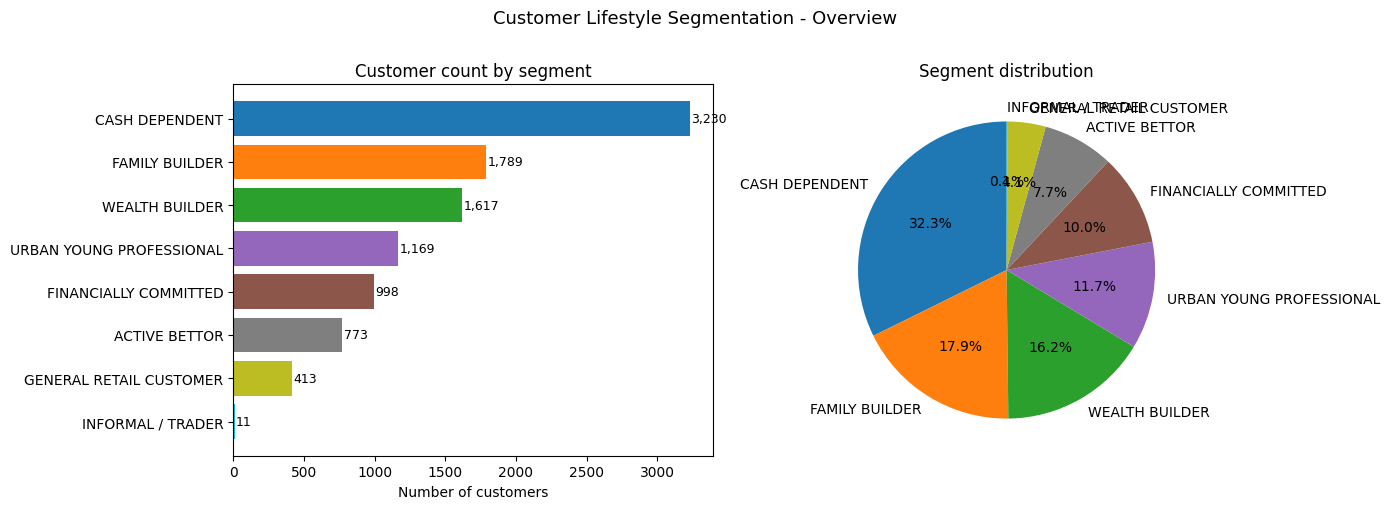

In [22]:
# 6b. Segment distribution charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_counts = df_features['SEGMENT_NAME'].value_counts()
colors     = plt.cm.tab10(np.linspace(0, 1, len(seg_counts)))

axes[0].barh(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_xlabel('Number of customers')
axes[0].set_title('Customer count by segment')
axes[0].invert_yaxis()
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

pct = seg_counts / seg_counts.sum() * 100
axes[1].pie(pct, labels=pct.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Segment distribution')
plt.suptitle('Customer Lifestyle Segmentation - Overview', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


In [23]:
# 6c. Segment behavioural profiles
_share_cols = [c for c in df_features.columns if c.endswith('_SHARE')]
df_seg_summary = df_features.groupby('SEGMENT_NAME').agg(
    CUSTOMER_COUNT=('CUSTOMER_ID','count'),
    AVG_SPEND=('TOTAL_SPEND','mean'),
    AVG_INFLOW=('TOTAL_INFLOW','mean'),
).sort_values('CUSTOMER_COUNT', ascending=False)

print("=" * 65)
print("SEGMENT PROFILES")
print("=" * 65)
for seg_name, seg_row in df_seg_summary.iterrows():
    print(f"\n  {seg_name}  ({int(seg_row['CUSTOMER_COUNT']):,} customers)")
    print(f"    Avg spend  : N{seg_row['AVG_SPEND']:>14,.0f}")
    print(f"    Avg inflow : N{seg_row['AVG_INFLOW']:>14,.0f}")
    top3 = (df_features.loc[df_features['SEGMENT_NAME']==seg_name, _share_cols]
            .mean().sort_values(ascending=False).head(3))
    for col, val in top3.items():
        label = col.replace('_SHARE','').replace('_',' ').title()
        print(f"    {label:<35s} {val*100:5.1f}%")


SEGMENT PROFILES

  CASH DEPENDENT  (3,230 customers)
    Avg spend  : N     3,995,380
    Avg inflow : N     1,155,283
    Cash Withdrawal                      57.2%
    Transfer To Others                   16.1%
    Food And Dining                       6.0%

  FAMILY BUILDER  (1,789 customers)
    Avg spend  : N     3,211,809
    Avg inflow : N     2,141,727
    Cash Withdrawal                      19.8%
    Transfer To Others                   12.7%
    Education                            10.2%

  WEALTH BUILDER  (1,617 customers)
    Avg spend  : N     7,606,375
    Avg inflow : N     6,641,783
    Transfer To Others                   22.3%
    Savings And Investments              14.5%
    Cash Withdrawal                      10.8%

  URBAN YOUNG PROFESSIONAL  (1,169 customers)
    Avg spend  : N     1,969,456
    Avg inflow : N     1,278,591
    Cash Withdrawal                      15.8%
    Food And Dining                      12.4%
    Transport And Logistics              11.

In [24]:
# 6d. Classification tier coverage
print("=" * 60)
print("DEBIT CLASSIFICATION COVERAGE")
print("=" * 60)
for t in sorted(_debit_tier_counts, key=str):
    cnt = _debit_tier_counts[t]
    print(f"  Tier {t}: {cnt:,}  ({cnt/_n_debit_total*100:.1f}%)")
print(f"  NO MAPPING: {_no_map}  <- must be 0")
assert _no_map == 0, f"CRITICAL: {_no_map:,} unclassified transactions"
print("Zero NO MAPPING confirmed")


DEBIT CLASSIFICATION COVERAGE
  Tier 2: 1,701,333  (68.1%)
  Tier 4: 796,752  (31.9%)
  NO MAPPING: 0  <- must be 0
Zero NO MAPPING confirmed


## Section 7: Customer Profile Lookup

Two interactive widgets for exploring individual customer data.

- **Widget 7a:** Full lifestyle profile - spending breakdown, income sources, segment, ratios
- **Widget 7b:** Raw transaction drill-down - classified debit, card, and credit detail tables

Both widgets load data on demand from classified parquets - no full dataset stays in memory.


In [25]:
# Period options shared by both widgets
import ipywidgets as widgets
from IPython.display import display, clear_output
import html as _html
import io, sys

_PERIOD_OPTIONS = [
    ('All data (Jul 2025 - Jun 2026)', (None, None)),
    # Monthly
    ('Jul 2025', ('2025-07-01', '2025-07-31')),
    ('Aug 2025', ('2025-08-01', '2025-08-31')),
    ('Sep 2025', ('2025-09-01', '2025-09-30')),
    ('Oct 2025', ('2025-10-01', '2025-10-31')),
    ('Nov 2025', ('2025-11-01', '2025-11-30')),
    ('Dec 2025', ('2025-12-01', '2025-12-31')),
    ('Jan 2026', ('2026-01-01', '2026-01-31')),
    ('Feb 2026', ('2026-02-01', '2026-02-28')),
    ('Mar 2026', ('2026-03-01', '2026-03-31')),
    ('Apr 2026', ('2026-04-01', '2026-04-30')),
    ('May 2026', ('2026-05-01', '2026-05-31')),
    ('Jun 2026', ('2026-06-01', '2026-06-30')),
    # Quarters / halves
    ('Q3 2025 (Jul-Sep)', ('2025-07-01', '2025-09-30')),
    ('Q4 2025 (Oct-Dec)', ('2025-10-01', '2025-12-31')),
    ('H2 2025 (Jul-Dec)', ('2025-07-01', '2025-12-31')),
    ('Q1 2026 (Jan-Mar)', ('2026-01-01', '2026-03-31')),
    ('Q2 2026 (Apr-Jun)', ('2026-04-01', '2026-06-30')),
    ('H1 2026 (Jan-Jun)', ('2026-01-01', '2026-06-30')),
    # 6M windows
    ('Prior 6M (Jul-Dec 2025)',   ('2025-07-01', '2025-12-31')),
    ('Recent 6M (Jan-Jun 2026)',  ('2026-01-01', '2026-06-30')),
]

# Helper: load classified transactions for one customer from parquets
def _load_customer_transactions(cid, target_months, cache_dir):
    deb_parts, pos_parts, crd_parts = [], [], []
    for f in sorted(glob.glob(os.path.join(cache_dir, 'df_debit_classified_*.parquet'))):
        if not any(m in os.path.basename(f) for m in target_months): continue
        p = pd.read_parquet(f, filters=[('CUSTOMER_ID','==',cid)])
        if len(p): deb_parts.append(p)
    for f in sorted(glob.glob(os.path.join(cache_dir, 'df_pos_classified_*.parquet'))):
        if not any(m in os.path.basename(f) for m in target_months): continue
        p = pd.read_parquet(f, filters=[('CUSTOMER_ID','==',cid)])
        if len(p): pos_parts.append(p)
    for f in sorted(glob.glob(os.path.join(cache_dir, 'df_credit_classified_*.parquet'))):
        if not any(m in os.path.basename(f) for m in target_months): continue
        p = pd.read_parquet(f, filters=[('CUSTOMER_ID','==',cid)])
        if len(p): crd_parts.append(p)

    _empty_deb = pd.DataFrame(columns=['CUSTOMER_ID','DR_ACCOUNT','TRN_CHANNEL',
                                        'AMOUNT','TRN_DATE','NARRATION','CATEGORY','TIER_USED'])
    _empty_pos = pd.DataFrame(columns=['CUSTOMER_ID','DR_ACCOUNT','TRN_CHANNEL',
                                        'MCC_CODE','MERCHANT_NAME_LOC','AMOUNT','TRN_DATE',
                                        'CATEGORY','TIER_USED'])
    _empty_crd = pd.DataFrame(columns=['CUSTOMER_ID','CR_ACCOUNT','TRN_CHANNEL',
                                        'AMOUNT','TRN_DATE','NARRATION','INCOME_SOURCE'])
    df_deb = pd.concat(deb_parts, ignore_index=True) if deb_parts else _empty_deb
    df_pos = pd.concat(pos_parts, ignore_index=True) if pos_parts else _empty_pos
    df_crd = pd.concat(crd_parts, ignore_index=True) if crd_parts else _empty_crd
    return df_deb, df_pos, df_crd


def _date_filter(df, start, end):
    if df.empty or (not start and not end): return df
    df = df.copy()
    df['TRN_DATE'] = pd.to_datetime(df['TRN_DATE'], errors='coerce')
    if start: df = df[df['TRN_DATE'] >= pd.Timestamp(start)]
    if end:   df = df[df['TRN_DATE'] <= pd.Timestamp(end)]
    return df

print("Widget helpers loaded")
print(f"  Period options : {len(_PERIOD_OPTIONS)}")


Widget helpers loaded
  Period options : 21


In [35]:
# Widget 7a: Customer Lifestyle Profile
# Period dropdown + Customer ID input + Look Up button
# Shows spending breakdown, income sources, behavioural ratios, segment assignment.

try: _profile_box.close()
except: pass

_p_period = widgets.Dropdown(
    options=_PERIOD_OPTIONS, value=(None,None),
    description='Period:',
    layout=widgets.Layout(width='280px'),
)
_p_input = widgets.Text(
    placeholder='e.g. CUST0000123',
    description='Customer ID:',
    layout=widgets.Layout(width='300px'),
)
_p_btn = widgets.Button(
    description='Look Up',
    button_style='primary',
    layout=widgets.Layout(width='100px'),
)
_p_status = widgets.Label(value='')
_p_result = widgets.HTML(
    value='<pre style="font-family:monospace;font-size:13px;color:#888">'
          '(Select a period, enter a Customer ID, and click Look Up)</pre>',
    layout=widgets.Layout(width='100%'),
)

def _on_lookup(_=None):
    cid = str(_p_input.value).strip()
    if not cid: return
    start, end = _p_period.value
    _p_status.value = f'Loading {cid}...'

    # Feature row
    feat_row = df_features[df_features['CUSTOMER_ID'] == cid]
    if feat_row.empty:
        _p_result.value = f'<pre>Customer <b>{_html.escape(cid)}</b> not found.</pre>'
        _p_status.value = ''
        return
    cust = feat_row.iloc[0]

    # Load transactions on demand
    df_deb, df_pos, df_crd = _load_customer_transactions(cid, TARGET_MONTHS, CACHE_DIR)

    # Date filter
    df_deb = _date_filter(df_deb, start, end)
    df_pos = _date_filter(df_pos, start, end)
    df_crd = _date_filter(df_crd, start, end)
    df_all_debit = pd.concat([df_deb, df_pos], ignore_index=True)

    # Debit aggregation
    if df_all_debit.empty:
        debit_summary = pd.Series(dtype=float)
        total_spend   = 0.0
    else:
        debit_summary = df_all_debit.groupby('CATEGORY')['AMOUNT'].sum().sort_values(ascending=False)
        total_spend   = float(debit_summary.sum())
    debit_txn_count = len(df_all_debit)

    # Recompute segment from filtered window
    _share_row = {f'{cat}_SHARE': amt/total_spend if total_spend > 0 else 0
                  for cat, amt in debit_summary.items()}
    _share_row['TOTAL_SPEND'] = total_spend
    segment      = assign_segment_name_individual(pd.Series(_share_row))
    similar_cnt  = int((df_features['SEGMENT_NAME'] == segment).sum())

    # Credit aggregation
    if df_crd.empty:
        credit_summary = pd.Series(dtype=float)
        total_inflow   = 0.0
    else:
        credit_col     = 'INCOME_SOURCE' if 'INCOME_SOURCE' in df_crd.columns else 'CATEGORY'
        credit_summary = df_crd.groupby(credit_col)['AMOUNT'].sum().sort_values(ascending=False)
        total_inflow   = float(credit_summary.sum())

    # Ratios from filtered data
    dti_ratio     = total_spend / total_inflow if total_inflow > 0 else 0.0
    cash_amt      = float(debit_summary.get('CASH_WITHDRAWAL', 0))
    cash_ratio    = cash_amt / total_spend if total_spend > 0 else 0.0
    digital_cnt   = int(df_deb['TRN_CHANNEL'].isin({'NIP','MOBILE','USSD'}).sum()) if not df_deb.empty else 0
    digital_ratio = digital_cnt / debit_txn_count if debit_txn_count > 0 else 0.0
    avg_ticket    = total_spend / debit_txn_count if debit_txn_count > 0 else 0.0

    # Period label
    if start or end:
        _sl = pd.Timestamp(start).strftime('%b %Y') if start else 'start'
        _el = pd.Timestamp(end).strftime('%b %Y') if end else 'now'
        period_lbl = f'{_sl} - {_el}'
    else:
        period_lbl = 'All data (Jul 2025 - Jun 2026)'

    # Build output
    buf = io.StringIO()
    def _p(line=''): buf.write(line + '\n')

    W = 62
    _p('=' * W)
    _p('  CUSTOMER LIFESTYLE PROFILE')
    _p(f'  Customer ID : {cid}')
    _p(f'  Period      : {period_lbl}')
    _p('=' * W)

    _p('\nDEBIT (SPENDING) BREAKDOWN')
    _p('-' * W)
    for cat, amt in debit_summary.items():
        pct = amt / total_spend * 100 if total_spend > 0 else 0
        bar = '█' * max(1, int(pct / 4))
        label = cat.replace('_',' ').title()
        _p(f'  {label:<28s} N{amt:>12,.0f}  {pct:5.1f}%  {bar}')
    _p('-' * W)
    _p(f'  {"Total Debit":<28s} N{total_spend:>12,.0f}   ({debit_txn_count:,} transactions)')

    # Channel breakdown
    _p('\nCHANNEL BREAKDOWN (DEBIT)')
    _p('-' * W)
    if not df_all_debit.empty and 'TRN_CHANNEL' in df_all_debit.columns:
        ch = (df_all_debit.groupby('TRN_CHANNEL')['AMOUNT']
              .agg(Count='count', Value='sum')
              .sort_values('Value', ascending=False))
        for chan, row in ch.iterrows():
            pct = row['Value']/total_spend*100 if total_spend > 0 else 0
            _p(f'  {str(chan):<18s}  {int(row["Count"]):>8,} txns  N{row["Value"]:>12,.0f}  {pct:5.1f}%')

    _p('\nCREDIT (INCOME) BREAKDOWN')
    _p('-' * W)
    if credit_summary.empty:
        _p('  No credit transactions this period.')
    else:
        for src, amt in credit_summary.items():
            sal_tag = '  [Regular salary pattern]' if (src == 'SALARY' and int(cust.get('IS_SALARY_EARNER',0))) else ''
            label   = src.replace('_',' ').title()
            _p(f'  {label:<28s} N{amt:>12,.0f}{sal_tag}')
        _p('-' * W)
        _p(f'  {"Total Inflow":<28s} N{total_inflow:>12,.0f}   ({len(df_crd):,} transactions)')

    _p()
    _p(f'  LIFESTYLE SEGMENT  : {segment}')
    _p(f'  SIMILAR CUSTOMERS  : {similar_cnt:,} customers share this segment (global model)')
    _p()
    _p(f'  Debit-to-credit ratio : {dti_ratio:.1%}')
    _p(f'  Digital txn ratio     : {digital_ratio:.1%}')
    _p(f'  Cash ratio            : {cash_ratio:.1%}')
    _p(f'  Avg ticket size       : N{avg_ticket:,.0f}')
    _p('=' * W)

    _p_result.value = (
        '<pre style="font-family:monospace;font-size:12px;line-height:1.5">'
        + _html.escape(buf.getvalue())
        + '</pre>'
    )
    _p_status.value = ''

_p_input.on_submit(_on_lookup)
_p_btn.on_click(_on_lookup)

_profile_box = widgets.VBox([
    widgets.HTML('<h4 style="margin:4px 0">Customer Lifestyle Profile</h4>'),
    widgets.HBox([_p_period, _p_input, _p_btn, _p_status]),
    _p_result,
])
clear_output(wait=False)
display(_profile_box)


In [31]:
# Widget 7b: Transaction Drill-Down
# Period dropdown + Customer ID input + Inspect button
# Shows raw classified debit, POS/card, credit tables with category totals.

try: _drill_box.close()
except: pass

_d_period = widgets.Dropdown(
    options=_PERIOD_OPTIONS, value=(None,None),
    description='Period:',
    layout=widgets.Layout(width='280px'),
)
_d_input = widgets.Text(
    placeholder='e.g. CUST0000123',
    description='Customer ID:',
    layout=widgets.Layout(width='300px'),
)
_d_btn = widgets.Button(
    description='Inspect',
    button_style='warning',
    layout=widgets.Layout(width='100px'),
)
_d_status = widgets.Label(value='')
_d_result = widgets.HTML(
    value='<p style="color:#888">(Select a period, enter a Customer ID, and click Inspect)</p>',
    layout=widgets.Layout(width='100%'),
)

def _on_inspect(_=None):
    cid = str(_d_input.value).strip()
    if not cid: return
    start, end = _d_period.value
    _d_status.value = f'Loading {cid}...'

    feat_row = df_features[df_features['CUSTOMER_ID'] == cid]
    if feat_row.empty:
        _d_result.value = f'<p>Customer <b>{_html.escape(cid)}</b> not found in dataset.</p>'
        _d_status.value = ''
        return

    seg = assign_segment_name_individual(feat_row.iloc[0])

    if start or end:
        _sl = pd.Timestamp(start).strftime('%b %Y') if start else 'start'
        _el = pd.Timestamp(end).strftime('%b %Y') if end else 'now'
        period_lbl = f'{_sl} - {_el}'
    else:
        period_lbl = 'All data (Jul 2025 - Jun 2026)'

    # Load and filter transactions
    df_deb, df_pos, df_crd = _load_customer_transactions(cid, TARGET_MONTHS, CACHE_DIR)
    df_deb = _date_filter(df_deb, start, end)
    df_pos = _date_filter(df_pos, start, end)
    df_crd = _date_filter(df_crd, start, end)
    df_all = pd.concat([df_deb, df_pos], ignore_index=True)

    parts = []
    parts.append(
        f'<b>Customer:</b> {_html.escape(cid)} &nbsp;'
        f'<b>Segment:</b> {_html.escape(str(seg))} &nbsp;'
        f'<b>Period:</b> {_html.escape(period_lbl)}<hr/>'
    )

    # DEBIT table
    deb_show_cols = [c for c in ['TRN_DATE','TRN_CHANNEL','NARRATION','AMOUNT','CATEGORY','TIER_USED']
                     if not df_deb.empty and c in df_deb.columns]
    deb_disp = df_deb[deb_show_cols].sort_values('TRN_DATE') if deb_show_cols else pd.DataFrame()
    parts.append(f'<h4>DEBIT (USSD/NIP/MOBILE/BRANCH): {len(deb_disp):,} rows</h4>')
    if not deb_disp.empty:
        parts.append(deb_disp.reset_index(drop=True).to_html(
            border=0, classes='dataframe',
            float_format=lambda x: f'{x:,.2f}'
        ))

    # POS/Card table
    pos_show_cols = [c for c in ['TRN_DATE','TRN_CHANNEL','MCC_CODE','MERCHANT_NAME_LOC','AMOUNT','CATEGORY','TIER_USED']
                     if not df_pos.empty and c in df_pos.columns]
    pos_disp = df_pos[pos_show_cols].sort_values('TRN_DATE') if pos_show_cols else pd.DataFrame()
    parts.append(f'<h4>POS / ATM / Card: {len(pos_disp):,} rows</h4>')
    if not pos_disp.empty:
        parts.append(pos_disp.reset_index(drop=True).to_html(
            border=0, classes='dataframe',
            float_format=lambda x: f'{x:,.2f}'
        ))

    # Combined category totals
    if not df_all.empty and 'CATEGORY' in df_all.columns:
        cat_totals = (
            df_all.groupby('CATEGORY')['AMOUNT']
            .agg(Total='sum', Count='count')
            .assign(Pct=lambda x: (x['Total'] / x['Total'].sum() * 100).round(1))
            .sort_values('Total', ascending=False)
        )
        cat_totals['Total'] = cat_totals['Total'].map('{:,.2f}'.format)
        parts.append(f'<h4>Category totals — combined debit+card ({len(df_all):,} transactions):</h4>')
        parts.append(cat_totals.to_html(border=0, classes='dataframe'))

    # Tier breakdown
    if not df_all.empty and 'TIER_USED' in df_all.columns:
        tier_counts = df_all['TIER_USED'].astype(str).value_counts().sort_index()
        parts.append('<h4>Classification tier breakdown:</h4>')
        parts.append(tier_counts.to_frame('Count').to_html(border=0, classes='dataframe'))

    # Credit table
    crd_show_cols = [c for c in ['TRN_DATE','TRN_CHANNEL','NARRATION','AMOUNT','INCOME_SOURCE']
                     if not df_crd.empty and c in df_crd.columns]
    crd_disp = df_crd[crd_show_cols].sort_values('TRN_DATE') if crd_show_cols else pd.DataFrame()
    parts.append(f'<h4>CREDIT (inflows): {len(crd_disp):,} rows</h4>')
    if not crd_disp.empty:
        parts.append(crd_disp.reset_index(drop=True).to_html(
            border=0, classes='dataframe',
            float_format=lambda x: f'{x:,.2f}'
        ))
        inc_totals = (
            df_crd.groupby('INCOME_SOURCE')['AMOUNT']
            .agg(Total='sum', Count='count')
            .assign(Pct=lambda x: (x['Total'] / x['Total'].sum() * 100).round(1))
            .sort_values('Total', ascending=False)
        )
        inc_totals['Total'] = inc_totals['Total'].map('{:,.2f}'.format)
        parts.append('<h4>Credit income totals:</h4>')
        parts.append(inc_totals.to_html(border=0, classes='dataframe'))

    _d_result.value = (
        '<style>.dataframe{border-collapse:collapse;font-size:12px}'
        '.dataframe td,.dataframe th{padding:3px 8px;border:1px solid #ddd}'
        '.dataframe tr:nth-child(even){background:#f9f9f9}</style>'
        + '\n'.join(parts)
    )
    _d_status.value = ''

_d_input.on_submit(_on_inspect)
_d_btn.on_click(_on_inspect)

_drill_box = widgets.VBox([
    widgets.HTML('<h4 style="margin:4px 0">Transaction Drill-Down</h4>'),
    widgets.HBox([_d_period, _d_input, _d_btn, _d_status]),
    _d_result,
])
clear_output(wait=False)
display(_drill_box)


## Section 8: Export Results

Builds the final customer segment output table with:
- Segment labels for 12M, prior 6M, and recent 6M windows (drift detection)
- TOP5 spend categories (category, share %, count, amount)
- TOP5 credit income sources
- PRIMARY_CHANNEL (most frequent transaction channel)
- DIGITAL_RATIO and RECOMMENDED_PRODUCT
- REPORT_DATE

In production this writes to two database tables:
- `SCHEMA.CUST_LIFESTYLE_SEGMENT` - snapshot, truncated and reloaded each run
- `SCHEMA.CUST_LIFESTYLE_SEGMENT_HIST` - history, one row per customer per REPORT_DATE


In [28]:
# 8a. Build prior 6M and recent 6M segment windows (drift detection)
def _build_features_for_window(target_months):
    _digital_ch = {'MOBILE','NIP','NEFT','WEB'}
    _d_parts, _c_parts = [], []

    for f in sorted(glob.glob(os.path.join(CACHE_DIR, 'df_debit_classified_*.parquet'))):
        if not any(m in os.path.basename(f) for m in target_months): continue
        pf = pd.read_parquet(f, columns=['CUSTOMER_ID','CATEGORY','AMOUNT','TRN_CHANNEL'])
        _d_parts.append(pf.groupby(['CUSTOMER_ID','CATEGORY'])['AMOUNT'].sum().reset_index())
        del pf
    for f in sorted(glob.glob(os.path.join(CACHE_DIR, 'df_pos_classified_*.parquet'))):
        if not any(m in os.path.basename(f) for m in target_months): continue
        pf = pd.read_parquet(f, columns=['CUSTOMER_ID','CATEGORY','AMOUNT'])
        pf = pf[pf['CATEGORY'] != 'CARD_REFUND']
        _d_parts.append(pf.groupby(['CUSTOMER_ID','CATEGORY'])['AMOUNT'].sum().reset_index())
        del pf
    for f in sorted(glob.glob(os.path.join(CACHE_DIR, 'df_credit_classified_*.parquet'))):
        if not any(m in os.path.basename(f) for m in target_months): continue
        pf = pd.read_parquet(f, columns=['CUSTOMER_ID','INCOME_SOURCE','AMOUNT'])
        _c_parts.append(pf.groupby(['CUSTOMER_ID','INCOME_SOURCE'])['AMOUNT'].sum().reset_index())
        del pf

    if not _d_parts:
        return pd.DataFrame(columns=['CUSTOMER_ID','SEGMENT_NAME'])

    _d_agg = (pd.concat(_d_parts, ignore_index=True)
                .groupby(['CUSTOMER_ID','CATEGORY'])['AMOUNT'].sum().reset_index()
                .rename(columns={'AMOUNT':'TOTAL_SPEND'}))
    _d_pivot = (_d_agg.pivot_table(index='CUSTOMER_ID', columns='CATEGORY',
                                    values='TOTAL_SPEND', aggfunc='sum', fill_value=0).reset_index())
    _d_pivot.columns.name = None
    _d_amt = [c for c in _d_pivot.columns if c != 'CUSTOMER_ID']
    _d_pivot['TOTAL_SPEND'] = _d_pivot[_d_amt].sum(axis=1)
    for col in _d_amt:
        _d_pivot[f'{col}_SHARE'] = np.where(
            _d_pivot['TOTAL_SPEND'] > 0, _d_pivot[col] / _d_pivot['TOTAL_SPEND'], 0
        )
    _d_pivot['SEGMENT_NAME'] = _d_pivot.apply(assign_segment_name_individual, axis=1)
    return _d_pivot[['CUSTOMER_ID','SEGMENT_NAME']]

print("Building prior 6M segment window...")
df_feat_prior  = _build_features_for_window(PRIOR_6M)
print(f"  {len(df_feat_prior):,} customers")
print("Building recent 6M segment window...")
df_feat_recent = _build_features_for_window(RECENT_6M)
print(f"  {len(df_feat_recent):,} customers")


Building prior 6M segment window...
  10,000 customers
Building recent 6M segment window...
  10,000 customers


In [33]:
# 8b. Assemble output dataframe
_product_map = {
    'ACTIVE BETTOR'            : 'Personal loan, airtime advance',
    'CASH DEPENDENT'           : 'Agent banking, basic savings',
    'FAMILY BUILDER'           : 'Education loan, family savings plan',
    'FINANCIALLY COMMITTED'    : 'Debt consolidation, salary advance',
    'GENERAL RETAIL CUSTOMER'  : 'Standard savings / everyday account',
    'INFORMAL / TRADER'        : 'Business account, SME lending',
    'MINIMAL ACTIVITY'         : 'Micro-savings account, reactivation offer',
    'STRATEGIST'               : 'Structured investment products, wealth advisory',
    'URBAN YOUNG PROFESSIONAL' : 'Personal loan, lifestyle card',
    'WEALTH BUILDER'           : 'Fixed deposit, investment advisory',
}

df_out = (
    df_features[['CUSTOMER_ID','SEGMENT_NAME']].rename(columns={'SEGMENT_NAME':'SEGMENT_12M'})
    .merge(df_feat_prior.rename(columns={'SEGMENT_NAME':'SEGMENT_6M_PRIOR'}),
           on='CUSTOMER_ID', how='left')
    .merge(df_feat_recent.rename(columns={'SEGMENT_NAME':'SEGMENT_6M_RECENT'}),
           on='CUSTOMER_ID', how='left')
)

df_out['SEGMENT_DRIFTED'] = (
    df_out['SEGMENT_6M_PRIOR'].notna()
    & df_out['SEGMENT_6M_RECENT'].notna()
    & (df_out['SEGMENT_6M_PRIOR'] != df_out['SEGMENT_6M_RECENT'])
).map({True:'Y', False:'N'})

df_out['DRIFT_DIRECTION'] = df_out.apply(
    lambda r: f"{r['SEGMENT_6M_PRIOR']} -> {r['SEGMENT_6M_RECENT']}"
              if r['SEGMENT_DRIFTED'] == 'Y' else None, axis=1
)

# TOP5 spend categories (lifestyle only)
_OP_SHARE = {
    'BANK_CHARGES_SHARE','TRANSFER_TO_SELF_SHARE','TRANSFER_TO_SELF_CROSSBANK_SHARE',
    'TRANSFER_TO_OTHERS_SHARE','BRANCH_TRANSACTION_SHARE','USSD_TRANSFER_SHARE',
    'MOBILE_TRANSFER_SHARE','WEB_PAYMENT_SHARE','ONLINE_PAYMENT_SHARE',
    'INTERBANK_TRANSFER_SHARE','UNCLASSIFIED_DEBIT_SHARE','POS_PURCHASE_SHARE',
}
_spend_share_cols = [c for c in df_features.columns
                     if c.endswith('_SHARE') and c not in _OP_SHARE]

def _top5_spend(row):
    vals = row[_spend_share_cols].sort_values(ascending=False)
    vals = vals[vals > 0]
    out  = {}
    for i, (col, pct) in enumerate(vals.head(5).items(), 1):
        cat = col.replace('_SHARE','')
        out[f'TOP{i}_SPEND_CAT'] = cat
        out[f'TOP{i}_SPEND_PCT'] = round(float(pct)*100, 2)
        out[f'TOP{i}_SPEND_VOL'] = int(row.get(f'{cat}_COUNT', 0) or 0)
        out[f'TOP{i}_SPEND_VAL'] = round(float(row.get(f'{cat}_AMT', 0) or 0), 2)
    return pd.Series(out)

_spend_top5 = df_features.set_index('CUSTOMER_ID').apply(_top5_spend, axis=1).reset_index()
df_out = df_out.merge(_spend_top5, on='CUSTOMER_ID', how='left')

# TOP5 credit income sources
def _top5_credit(row):
    amts  = row[credit_amt_cols]
    total = amts.sum()
    if total <= 0: return pd.Series()
    vals = (amts / total).sort_values(ascending=False)
    out  = {}
    for i, (col, pct) in enumerate(vals[vals > 0].head(5).items(), 1):
        cat = col.replace('_AMT','')
        out[f'TOP{i}_CREDIT_CAT'] = cat
        out[f'TOP{i}_CREDIT_PCT'] = round(float(pct)*100, 2)
        out[f'TOP{i}_CREDIT_VOL'] = int(row.get(f'{cat}_COUNT', 0) or 0)
        out[f'TOP{i}_CREDIT_VAL'] = round(float(row.get(col, 0) or 0), 2)
    return pd.Series(out)

_credit_top5 = df_features.set_index('CUSTOMER_ID').apply(_top5_credit, axis=1).reset_index()
df_out = df_out.merge(_credit_top5, on='CUSTOMER_ID', how='left')

# PRIMARY_CHANNEL
_ch_frames = []
for pat in ('df_debit_classified_*.parquet','df_pos_classified_*.parquet'):
    for f in sorted(glob.glob(os.path.join(CACHE_DIR, pat))):
        if not any(m in os.path.basename(f) for m in TARGET_MONTHS): continue
        pf = pd.read_parquet(f, columns=['CUSTOMER_ID','TRN_CHANNEL'])
        _ch_frames.append(pf.groupby(['CUSTOMER_ID','TRN_CHANNEL']).size().reset_index(name='CNT'))
        del pf

_ch_agg = pd.concat(_ch_frames, ignore_index=True).groupby(['CUSTOMER_ID','TRN_CHANNEL'])['CNT'].sum().reset_index()
_primary_ch = (_ch_agg.loc[_ch_agg.groupby('CUSTOMER_ID')['CNT'].idxmax(), ['CUSTOMER_ID','TRN_CHANNEL']]
               .rename(columns={'TRN_CHANNEL':'PRIMARY_CHANNEL'}))
df_out = df_out.merge(_primary_ch, on='CUSTOMER_ID', how='left')

# DIGITAL_RATIO and RECOMMENDED_PRODUCT
df_out = df_out.merge(
    df_features[['CUSTOMER_ID','DIGITAL_RATIO']].assign(
        DIGITAL_RATIO=lambda x: (x['DIGITAL_RATIO']*100).round(2)
    ), on='CUSTOMER_ID', how='left'
)
df_out['RECOMMENDED_PRODUCT'] = df_out['SEGMENT_12M'].map(_product_map)
df_out['REPORT_DATE']          = pd.to_datetime(REPORT_DATE)

# Transfer breakdown
_self_amt   = df_features.get('TRANSFER_TO_SELF_AMT', pd.Series(0, index=df_features.index))
_xbank_amt  = df_features.get('TRANSFER_TO_SELF_CROSSBANK_AMT', pd.Series(0, index=df_features.index))
_others_amt = df_features.get('TRANSFER_TO_OTHERS_AMT', pd.Series(0, index=df_features.index))
_safe_t     = df_features['TOTAL_SPEND'].replace(0, np.nan)
_transfer   = pd.DataFrame({
    'CUSTOMER_ID'              : df_features['CUSTOMER_ID'],
    'TRANSFER_TO_SELF_SHARE'   : ((_self_amt + _xbank_amt) / _safe_t).fillna(0).round(4),
    'TRANSFER_TO_SELF_VAL'     : (_self_amt + _xbank_amt).fillna(0).round(2),
    'TRANSFER_TO_OTHERS_SHARE' : (_others_amt / _safe_t).fillna(0).round(4),
    'TRANSFER_TO_OTHERS_VAL'   : _others_amt.fillna(0).round(2),
})
df_out = df_out.merge(_transfer, on='CUSTOMER_ID', how='left')
df_out = df_out.rename(columns={'CUSTOMER_ID':'CUSTOMER_NO'})

print(f"Output: {len(df_out):,} customers x {len(df_out.columns)} columns")
print(f"\nDrift summary:")
print(df_out['SEGMENT_DRIFTED'].value_counts().to_string())
print(f"\nTop drift directions:")
print(df_out[df_out['SEGMENT_DRIFTED']=='Y']['DRIFT_DIRECTION'].value_counts().head(10).to_string())
display(df_out[['CUSTOMER_NO','SEGMENT_12M','SEGMENT_6M_PRIOR','SEGMENT_6M_RECENT',
                'SEGMENT_DRIFTED','TOP1_SPEND_CAT','TOP1_SPEND_PCT',
                'PRIMARY_CHANNEL','RECOMMENDED_PRODUCT','REPORT_DATE']].head())


Output: 10,000 customers x 50 columns

Drift summary:
SEGMENT_DRIFTED
N    7610
Y    2390

Top drift directions:
DRIFT_DIRECTION
CASH DEPENDENT -> GENERAL RETAIL CUSTOMER              309
GENERAL RETAIL CUSTOMER -> CASH DEPENDENT              306
FAMILY BUILDER -> URBAN YOUNG PROFESSIONAL             239
URBAN YOUNG PROFESSIONAL -> FAMILY BUILDER             226
FAMILY BUILDER -> CASH DEPENDENT                       156
CASH DEPENDENT -> FAMILY BUILDER                       115
URBAN YOUNG PROFESSIONAL -> GENERAL RETAIL CUSTOMER    102
GENERAL RETAIL CUSTOMER -> FAMILY BUILDER               97
FAMILY BUILDER -> GENERAL RETAIL CUSTOMER               94
CASH DEPENDENT -> FINANCIALLY COMMITTED                 93


,CUSTOMER_NO,SEGMENT_12M,SEGMENT_6M_PRIOR,SEGMENT_6M_RECENT,SEGMENT_DRIFTED,TOP1_SPEND_CAT,TOP1_SPEND_PCT,PRIMARY_CHANNEL,RECOMMENDED_PRODUCT,REPORT_DATE
0,CUST0000001,CASH DEPENDENT,CASH DEPENDENT,CASH DEPENDENT,N,CASH_WITHDRAWAL,68.35,ATM,"Agent banking, basic savings",2026-06-30
1,CUST0000002,URBAN YOUNG PROFESSIONAL,URBAN YOUNG PROFESSIONAL,URBAN YOUNG PROFESSIONAL,N,FOOD_AND_DINING,13.77,POS,"Personal loan, lifestyle card",2026-06-30
2,CUST0000003,CASH DEPENDENT,CASH DEPENDENT,CASH DEPENDENT,N,CASH_WITHDRAWAL,75.01,ATM,"Agent banking, basic savings",2026-06-30
3,CUST0000004,ACTIVE BETTOR,ACTIVE BETTOR,ACTIVE BETTOR,N,BETTING_GAMES_AND_GAMBLING,26.49,NIP,"Personal loan, airtime advance",2026-06-30
4,CUST0000005,WEALTH BUILDER,FAMILY BUILDER,FAMILY BUILDER,N,SAVINGS_AND_INVESTMENTS,16.48,POS,"Fixed deposit, investment advisory",2026-06-30


In [34]:
# 8c. Save to CSV
out_path = os.path.join(OUTPUT_DIR,
    f'customer_lifestyle_segments_{pd.Timestamp(REPORT_DATE).strftime("%Y%m%d")}.csv')
df_out.to_csv(out_path, index=False)

print(f"Saved: {os.path.abspath(out_path)}")
print(f"Rows : {len(df_out):,}")
print(f"Cols : {len(df_out.columns)}")
print()
print("Segment distribution in output:")
print(df_out['SEGMENT_12M'].value_counts().to_string())


Saved: c:\G_py\customer_lifestyle_segmentation\outputs\customer_lifestyle_segments_20260630.csv
Rows : 10,000
Cols : 50

Segment distribution in output:
SEGMENT_12M
CASH DEPENDENT              3230
FAMILY BUILDER              1789
WEALTH BUILDER              1617
URBAN YOUNG PROFESSIONAL    1169
FINANCIALLY COMMITTED        998
ACTIVE BETTOR                773
GENERAL RETAIL CUSTOMER      413
INFORMAL / TRADER             11
